# 🎯 Système Intelligent Multi-Modèles pour la Rétention Client

> **Projet M1 Data Science** - Expert en Ingénierie de Données (RNCP40875 - Bloc 2)

Plateforme intelligente de prédiction du churn client et d'évaluation du risque de revenus pour entreprises SaaS, télécom et services par abonnement.

## Partie 1 : Analyse Exploratoire des Données (EDA)

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [2]:
BASE_PATH = Path.cwd().parent
DATA_PATH = BASE_PATH / "data"
IMG_PATH = BASE_PATH / "img"

CSV_PATH = DATA_PATH / "customer_churn_business_dataset.csv"

In [3]:
df = pd.read_csv(CSV_PATH)

df.head()

,customer_id,gender,age,country,city,customer_segment,tenure_months,signup_channel,contract_type,monthly_logins,...,avg_resolution_time,complaint_type,csat_score,escalations,email_open_rate,marketing_click_rate,nps_score,survey_response,referral_count,churn
0,CUST_00001,Male,68,Bangladesh,London,SME,22,Web,Monthly,26,...,13.354360,Service,4.0,0,0.71,0.40,27,Satisfied,1,0
1,CUST_00002,Female,57,Canada,Sydney,Individual,9,Mobile,Monthly,7,...,25.140088,Billing,2.0,0,0.78,0.33,-19,Neutral,2,1
2,CUST_00003,Male,24,Germany,New York,SME,58,Web,Yearly,19,...,27.572928,Service,3.0,0,0.35,0.49,80,Neutral,1,0
3,CUST_00004,Male,49,Australia,Dhaka,Individual,19,Mobile,Yearly,34,...,26.420822,Technical,5.0,1,0.83,0.15,100,Neutral,0,0
4,CUST_00005,Male,65,Bangladesh,Delhi,Individual,52,Web,Monthly,20,...,26.674579,Technical,4.0,0,0.65,0.44,21,Unsatisfied,1,0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 32 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   customer_id             10000 non-null  str    
 1   gender                  10000 non-null  str    
 2   age                     10000 non-null  int64  
 3   country                 10000 non-null  str    
 4   city                    10000 non-null  str    
 5   customer_segment        10000 non-null  str    
 6   tenure_months           10000 non-null  int64  
 7   signup_channel          10000 non-null  str    
 8   contract_type           10000 non-null  str    
 9   monthly_logins          10000 non-null  int64  
 10  weekly_active_days      10000 non-null  int64  
 11  avg_session_time        10000 non-null  float64
 12  features_used           10000 non-null  int64  
 13  usage_growth_rate       10000 non-null  float64
 14  last_login_days_ago     10000 non-null  int64  
 1

In [5]:
len(df)

10000

In [6]:
variables_numeriques = []
variables_categorielles = []
for col in df.columns:
    type = df[col].dtype
    if str(type).startswith("int") or str(type).startswith("float"):
        variables_numeriques.append(col)
    else:
        variables_categorielles.append(col)

print("Variables numériques :", variables_numeriques)

Variables numériques : ['age', 'tenure_months', 'monthly_logins', 'weekly_active_days', 'avg_session_time', 'features_used', 'usage_growth_rate', 'last_login_days_ago', 'monthly_fee', 'total_revenue', 'payment_failures', 'support_tickets', 'avg_resolution_time', 'csat_score', 'escalations', 'email_open_rate', 'marketing_click_rate', 'nps_score', 'referral_count', 'churn']


In [7]:
print("Variables catégorielles :", variables_categorielles)

Variables catégorielles : ['customer_id', 'gender', 'country', 'city', 'customer_segment', 'signup_channel', 'contract_type', 'payment_method', 'discount_applied', 'price_increase_last_3m', 'complaint_type', 'survey_response']


Le dataset **Customer Churn Business** contient **10 000 observations** (clients) et **31 colonnes** représentant différentes caractéristiques comportementales, démographiques et transactionnelles.

**Colonnes du Dataset** :

- `customer_id` : Identifiant unique du client
- `gender` : Genre du client (Male, Female)
- `country` : Pays du client
- `city` : Ville du client
- `customer_segment` : Segment de clientèle
- `tenure_months`: Ancienneté du client (mois)
- `signup_channel`: Méthode de connection (Web, Mobile, ...)
- `contract_type`: Type de contrat (Monthly, Annual, Two-Year)
- `monthly_logins`: Nombre de connexions mensuelles
- `weekly_active_days`: Nombre de jours actifs par semaine
- `avg_session_time`: Temps moyen de session
- `features_used`: Nombre de fonctionnalités utilisées
- `usage_growth_rate`: Taux de croissance de l'utilisation
- `last_login_days_ago`: Nombre de jours depuis la dernière connexion
- `monthly_fee`: Frais mensuels payés par le client ($)
- `total_revenue`: Revenu total généré par le client ($)
- `payment_method`: Méthode de paiement utilisée
- `payment_failures`: Nombre d'échecs de paiement
- `discount_applied`: Montant total des réductions appliquées ($)
- `price_increase_last_3m`: Indique si une augmentation de prix récente a eu lieu (true / false).
- `support_tickets`: Nombre de tickets support ouverts
- `avg_resolution_time`: Temps moyen de résolution des tickets (heures)
- `complaint_type`: Type de plainte au service client
- `csat_score`: Score de satisfaction client
- `escalations`: Nombre d'escalades service client
- `email_open_rate`: Taux d'ouverture des emails marketing (%)
- `marketing_click_rate`: Taux de clics sur les campagnes marketing (%)
- `nps_score`: Net Promoter Score (0-100) - indicateur de satisfaction
- `survey_response`: Taux de réponse aux enquêtes (%)
- `referral_count`: Nombre de parrainages effectués
- `churn`: Indicateur de résiliation (0 = Non, 1 = Oui) ← **Variable à prédire**

**Objectif** : Prédire la probabilité qu'un client résilie son abonnement (`churn = 1`) en se basant sur ces 30 features.


### Distribution de la variable cible `churn`

In [8]:
churn_counts = df['churn'].value_counts()
churn_percentages = df['churn'].value_counts(normalize=True) * 100

In [9]:
print("📊 DISTRIBUTION DE LA VARIABLE CIBLE : CHURN")
print()
print(f"\nNombre de clients par classe:")
print(f"  • Churn = 0 (Clients fidèles)  : {churn_counts[0]:,} ({churn_percentages[0]:.2f}%)")
print(f"  • Churn = 1 (Clients partis)   : {churn_counts[1]:,} ({churn_percentages[1]:.2f}%)")
print(f"\nTotal clients : {len(df):,}")
print(f"Taux de churn global : {churn_percentages[1]:.2f}%")

📊 DISTRIBUTION DE LA VARIABLE CIBLE : CHURN


Nombre de clients par classe:
  • Churn = 0 (Clients fidèles)  : 8,979 (89.79%)
  • Churn = 1 (Clients partis)   : 1,021 (10.21%)

Total clients : 10,000
Taux de churn global : 10.21%


In [10]:
moyenne_globale_churn = churn_percentages[1]
print(f"\nChurn moyen sur le dataset : {moyenne_globale_churn:.2f}%")


Churn moyen sur le dataset : 10.21%


In [11]:
# Calcul du revenu à risque
revenue_at_risk = df[df['churn'] == 1]['total_revenue'].sum()
total_revenue = df['total_revenue'].sum()
revenue_risk_pct = (revenue_at_risk / total_revenue) * 100

In [12]:
print(f"IMPACT BUSINESS:")
print(f"  • Revenu total généré      : ${total_revenue:,.2f}")
print(f"  • Revenu à risque (churners): ${revenue_at_risk:,.2f}")
print(f"  • Pourcentage à risque     : {revenue_risk_pct:.2f}%")

IMPACT BUSINESS:
  • Revenu total généré      : $10,570,180.00
  • Revenu à risque (churners): $862,640.00
  • Pourcentage à risque     : 8.16%


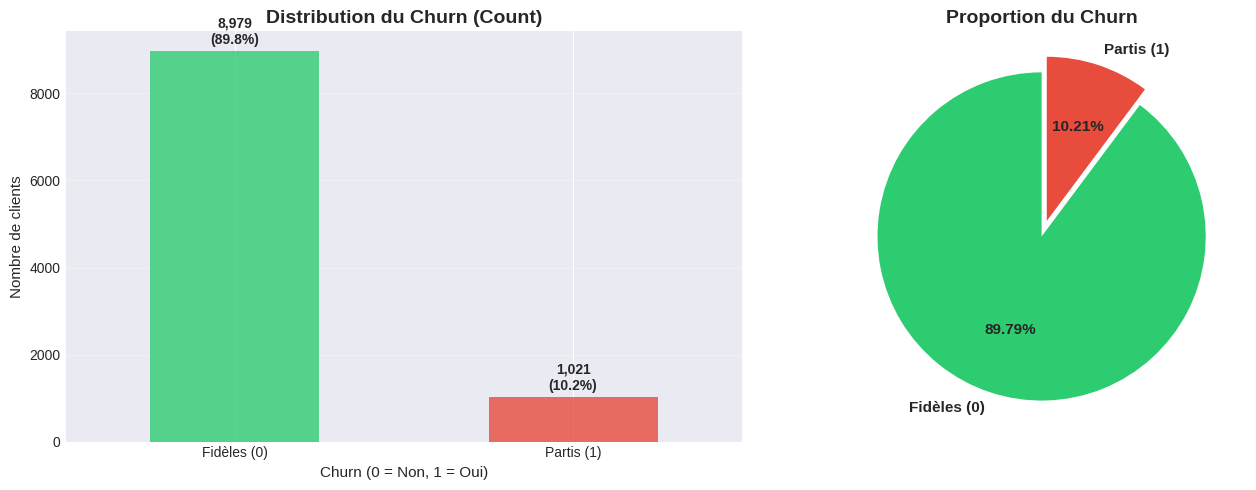

In [13]:
# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Graphique 1 : Barplot
churn_counts.plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'], alpha=0.8)
axes[0].set_title('Distribution du Churn (Count)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Churn (0 = Non, 1 = Oui)', fontsize=11)
axes[0].set_ylabel('Nombre de clients', fontsize=11)
axes[0].set_xticklabels(['Fidèles (0)', 'Partis (1)'], rotation=0)
axes[0].grid(axis='y', alpha=0.3)

# Ajouter les valeurs sur les barres
for i, v in enumerate(churn_counts):
    axes[0].text(i, v + 100, f'{v:,}\n({churn_percentages.iloc[i]:.1f}%)', 
                ha='center', va='bottom', fontweight='bold')

# Graphique 2 : Pie chart
colors = ['#2ecc71', '#e74c3c']
explode = (0, 0.1)  # Explode le segment churn=1
axes[1].pie(churn_counts, labels=['Fidèles (0)', 'Partis (1)'], autopct='%1.2f%%',
           colors=colors, explode=explode, startangle=90, textprops={'fontsize': 11, 'fontweight': 'bold'})
axes[1].set_title('Proportion du Churn', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(IMG_PATH / "eda_desequilibre_classe.png")
plt.show()

In [14]:
# Vérification du déséquilibre des classes
ratio = churn_counts[0] / churn_counts[1]
print(f"⚖️ DÉSÉQUILIBRE DES CLASSES:")
print(f"  Ratio (Fidèles / Partis) : {ratio:.2f}:1")

⚖️ DÉSÉQUILIBRE DES CLASSES:
  Ratio (Fidèles / Partis) : 8.79:1


Conclusion partielle : **le déséquilibre des classes est fort**, environ 90% / 10%. La majorité des clients sont fidèles (churn = 0), tandis qu'une minorité résilie (churn = 1). Ce déséquilibre devra être pris en compte lors de la modélisation pour éviter un biais vers la classe majoritaire. Il faudra envisager les points suivants :
- `class_weight='balanced'` dans TOUS les modèles
- Métriques prioritaires: Recall, F1-Score, PR-AUC (ROC-AUC)
- Ne surtout pas utiliser Accuracy comme métrique principale
- Stratified split OBLIGATOIRE (stratify=y)

A étudier : SMOTE, sous-échantillonnage ou ajustement du seuil de décision

### Identification des variables

Nous séparons les variables catégorielles des variables numériques. Elles seront traités différemment, dans l'EDA et dans le pré processing.

In [15]:
variables_categorielles = [
    "gender",
    "country",
    "city",
    "customer_segment",
    "signup_channel",
    "contract_type",
    "payment_method",
    "discount_applied",
    "price_increase_last_3m",
    "complaint_type",
    "survey_response",
]

In [63]:
variables_numeriques = [
    "age",
    "tenure_months",
    "monthly_logins",
    "weekly_active_days",
    "avg_session_time",
    "features_used",
    "usage_growth_rate",
    "last_login_days_ago",
    "monthly_fee",
    "total_revenue",
    "payment_failures",
    "support_tickets",
    "avg_resolution_time",
    "csat_score",
    "escalations",
    "email_open_rate",
    "marketing_click_rate",
    "nps_score",
    "referral_count"
]

## Analyse des variables catégorielles

In [17]:
print("Nombre de catégories par variable :")
for var in variables_categorielles:
    print(f"  • {var}: {df[var].nunique()} catégories uniques")

Nombre de catégories par variable :
  • gender: 2 catégories uniques
  • country: 7 catégories uniques
  • city: 7 catégories uniques
  • customer_segment: 3 catégories uniques
  • signup_channel: 3 catégories uniques
  • contract_type: 3 catégories uniques
  • payment_method: 3 catégories uniques
  • discount_applied: 2 catégories uniques
  • price_increase_last_3m: 2 catégories uniques
  • complaint_type: 3 catégories uniques
  • survey_response: 3 catégories uniques


In [18]:
def analyser_variable_categorielle(variable):
    """Analyse complète d'une variable catégorielle par rapport au churn."""
    print(f"ANALYSE DE LA VARIABLE: {variable.upper()}")
    
    # 1. Distribution générale
    print("\n* Distribution générale:")
    counts = df[variable].value_counts()
    percentages = df[variable].value_counts(normalize=True) * 100
    
    distrib = pd.DataFrame({
        'Count': counts,
        'Percentage': percentages
    })
    print(distrib)
    print(f"\nNombre de catégories: {df[variable].nunique()}")
    
    # 2. Taux de churn par catégorie
    print(f"\n* Taux de churn par catégorie de {variable}:")
    churn_by_cat = df.groupby(variable)['churn'].agg(['sum', 'count', 'mean'])
    churn_by_cat.columns = ['Churners', 'Total', 'Taux_Churn']
    churn_by_cat['Taux_Churn_Pct'] = churn_by_cat['Taux_Churn'] * 100
    churn_by_cat = churn_by_cat.sort_values('Taux_Churn_Pct', ascending=False)
    print(churn_by_cat)
    
    # 3. Visualisation
    print(f"\n* Visualisation:")
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    
    # Countplot avec hue
    sns.countplot(data=df, x=variable, ax=axes[0])
    axes[0].set_title(f'Distribution de {variable}', fontsize=12, fontweight='bold')
    axes[0].set_xlabel(variable, fontsize=10)
    axes[0].set_ylabel('Count', fontsize=10)
    axes[0].tick_params(axis='x', rotation=45)
    
    # Barplot du taux de churn
    churn_by_cat['Taux_Churn_Pct'].plot(kind='barh', ax=axes[1], color='#e74c3c', alpha=0.7)
    axes[1].set_title(f'Taux de Churn par {variable}', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Taux de Churn (%)', fontsize=10)
    axes[1].set_ylabel(variable, fontsize=10)
    axes[1].axvline(x=moyenne_globale_churn, color='blue', linestyle='--', label=f'Moyenne globale ({moyenne_globale_churn:.2f}%)')
    axes[1].legend()
    
    plt.tight_layout()
    plt.savefig(IMG_PATH / f"eda_categorielle_{variable}.png")
    plt.show()

ANALYSE DE LA VARIABLE: GENDER

* Distribution générale:
        Count  Percentage
gender                   
Male     5013       50.13
Female   4987       49.87

Nombre de catégories: 2

* Taux de churn par catégorie de gender:
        Churners  Total  Taux_Churn  Taux_Churn_Pct
gender                                             
Male         517   5013    0.103132       10.313186
Female       504   4987    0.101063       10.106276

* Visualisation:


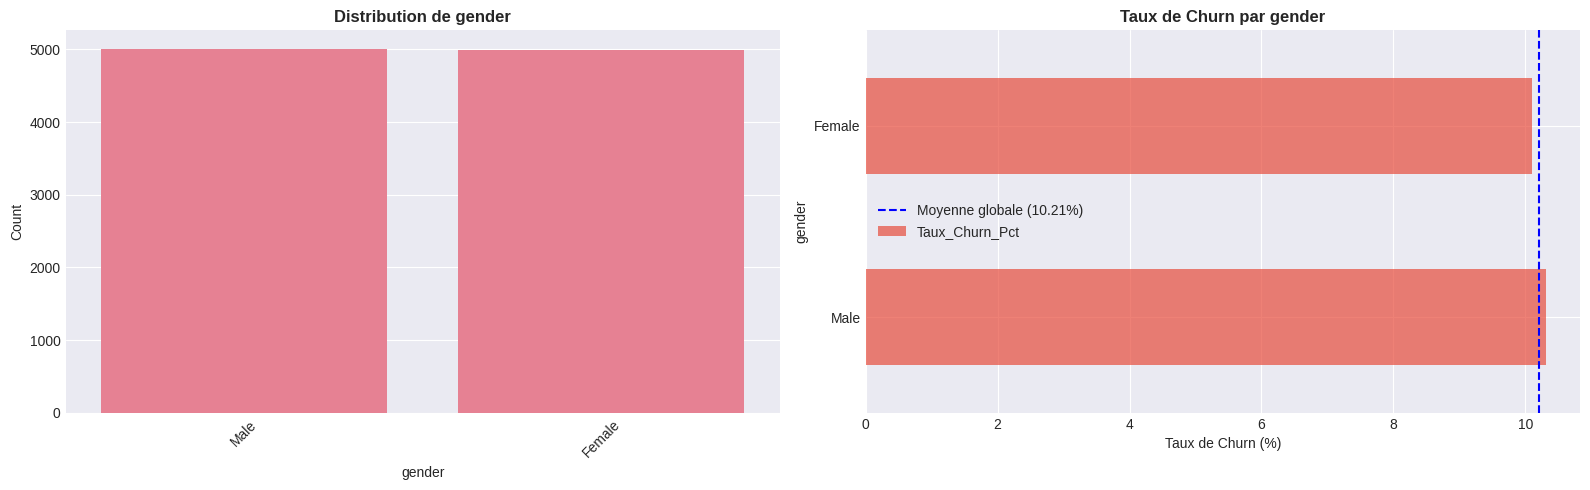

In [19]:
analyser_variable_categorielle("gender")

ANALYSE DE LA VARIABLE: COUNTRY

* Distribution générale:
            Count  Percentage
country                      
Bangladesh   1494       14.94
Canada       1488       14.88
USA          1442       14.42
India        1427       14.27
Australia    1400       14.00
UK           1382       13.82
Germany      1367       13.67

Nombre de catégories: 7

* Taux de churn par catégorie de country:
            Churners  Total  Taux_Churn  Taux_Churn_Pct
country                                                
Germany          157   1367    0.114850       11.485004
Australia        152   1400    0.108571       10.857143
UK               143   1382    0.103473       10.347323
Canada           152   1488    0.102151       10.215054
USA              146   1442    0.101248       10.124827
Bangladesh       140   1494    0.093708        9.370817
India            131   1427    0.091801        9.180098

* Visualisation:


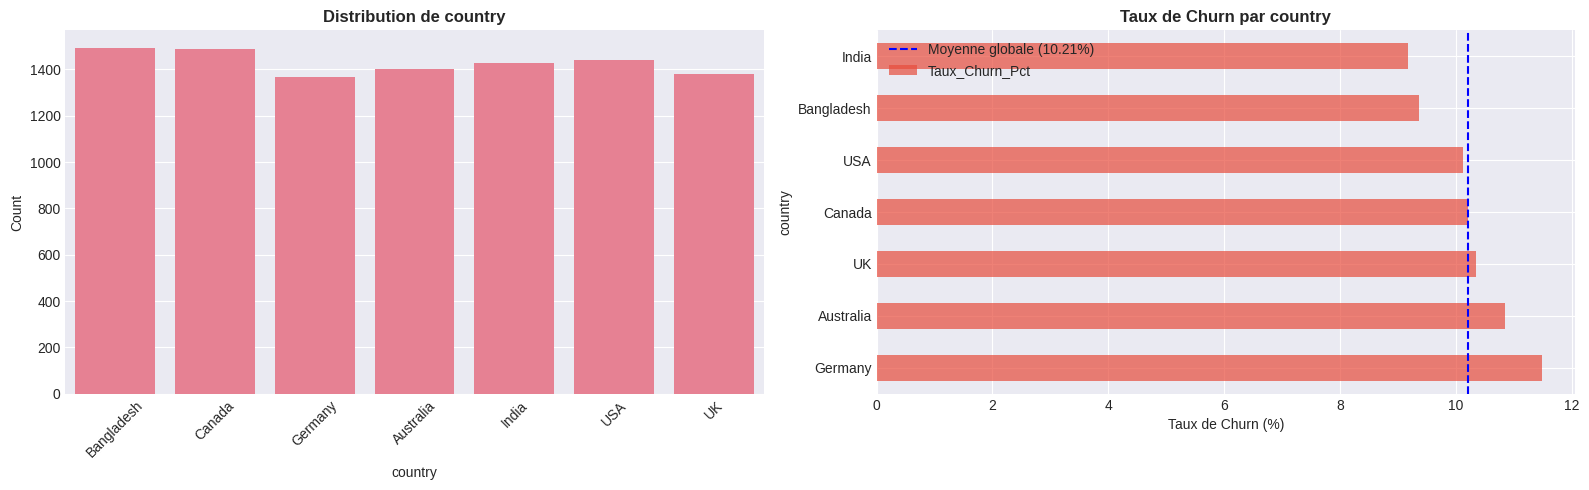

In [20]:
analyser_variable_categorielle("country")

ANALYSE DE LA VARIABLE: CITY

* Distribution générale:
          Count  Percentage
city                       
London     1518       15.18
Sydney     1471       14.71
Dhaka      1459       14.59
Delhi      1402       14.02
Berlin     1386       13.86
New York   1385       13.85
Toronto    1379       13.79

Nombre de catégories: 7

* Taux de churn par catégorie de city:
          Churners  Total  Taux_Churn  Taux_Churn_Pct
city                                                 
New York       154   1385    0.111191       11.119134
Toronto        147   1379    0.106599       10.659898
Sydney         156   1471    0.106050       10.605031
Delhi          148   1402    0.105563       10.556348
Dhaka          144   1459    0.098698        9.869774
Berlin         134   1386    0.096681        9.668110
London         138   1518    0.090909        9.090909

* Visualisation:


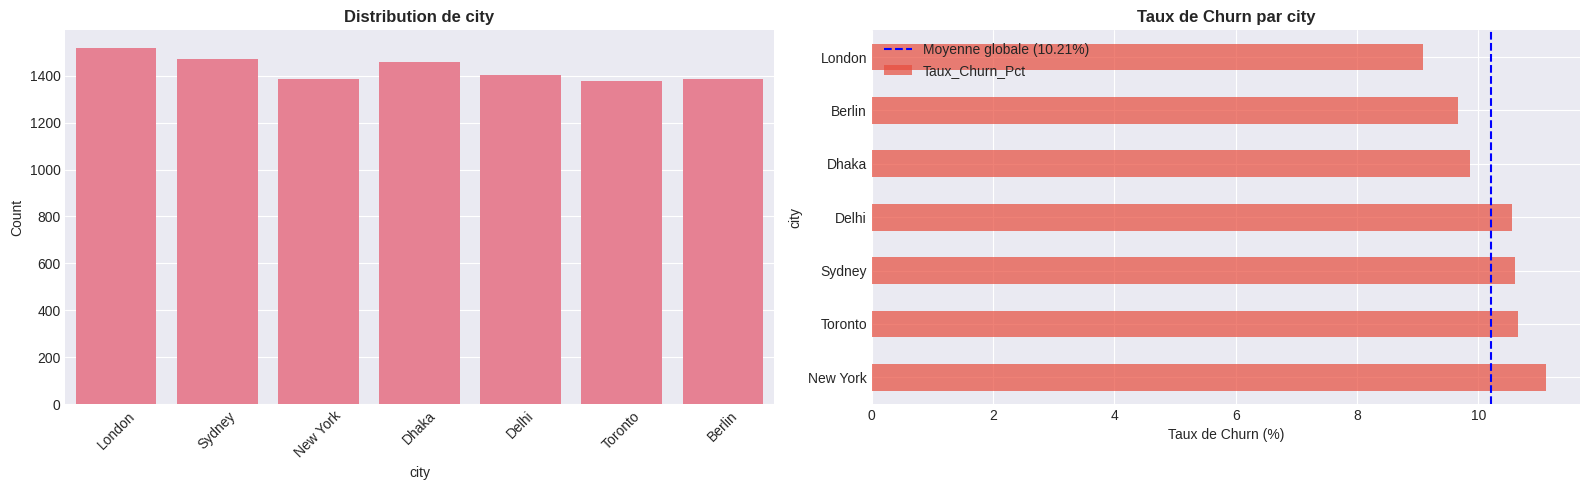

In [21]:
analyser_variable_categorielle("city")

Sur les 7 villes la distribution est plutôt uniforme. Notons cependant que certaines villes ont un taux de `churn` **légèrement plus élevé (New York, Torronto, Sydney)** et certaines un **taux plus bas (comme Londres ou Berlin)**.

ANALYSE DE LA VARIABLE: CUSTOMER_SEGMENT

* Distribution générale:
                  Count  Percentage
customer_segment                   
Individual         5984       59.84
SME                3029       30.29
Enterprise          987        9.87

Nombre de catégories: 3

* Taux de churn par catégorie de customer_segment:
                  Churners  Total  Taux_Churn  Taux_Churn_Pct
customer_segment                                             
SME                    331   3029    0.109277       10.927699
Individual             597   5984    0.099766        9.976604
Enterprise              93    987    0.094225        9.422492

* Visualisation:


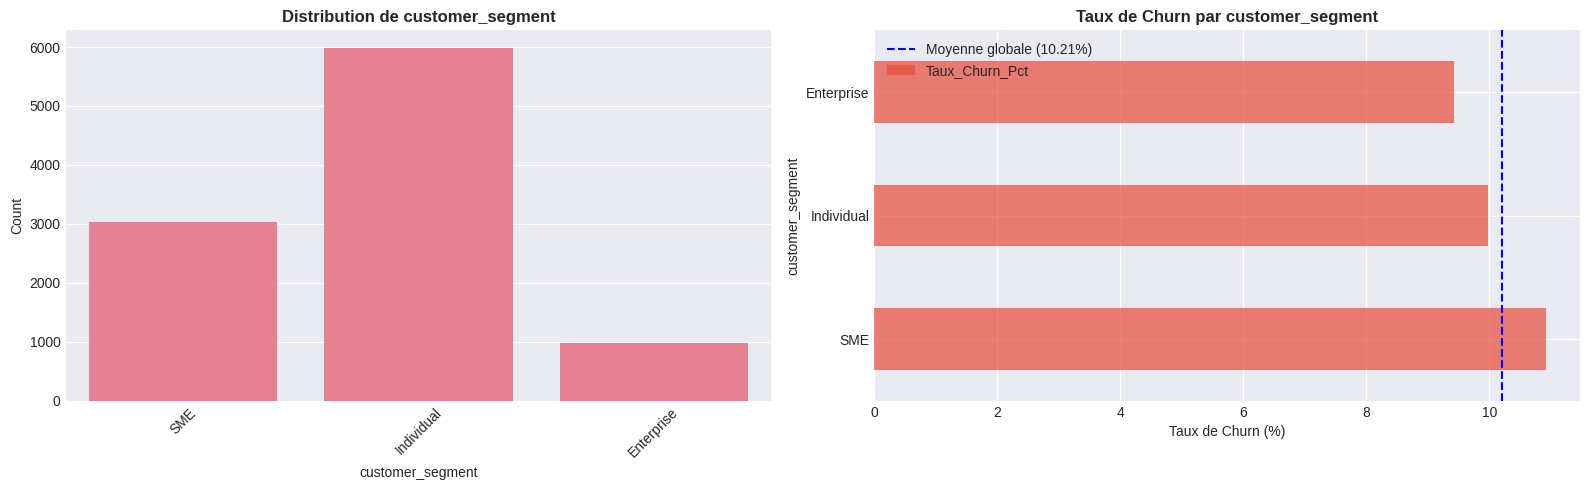

In [22]:
analyser_variable_categorielle("customer_segment")

Le segment client est majoritairement `individual` (60%). Le segment `SME` représente 30% du dataset, mais est concerné par un **taux de `churn` plus élevé que la moyenne**.

ANALYSE DE LA VARIABLE: SIGNUP_CHANNEL

* Distribution générale:
                Count  Percentage
signup_channel                   
Web              5036       50.36
Mobile           2960       29.60
Referral         2004       20.04

Nombre de catégories: 3

* Taux de churn par catégorie de signup_channel:
                Churners  Total  Taux_Churn  Taux_Churn_Pct
signup_channel                                             
Referral             224   2004    0.111776       11.177645
Mobile               296   2960    0.100000       10.000000
Web                  501   5036    0.099484        9.948372

* Visualisation:


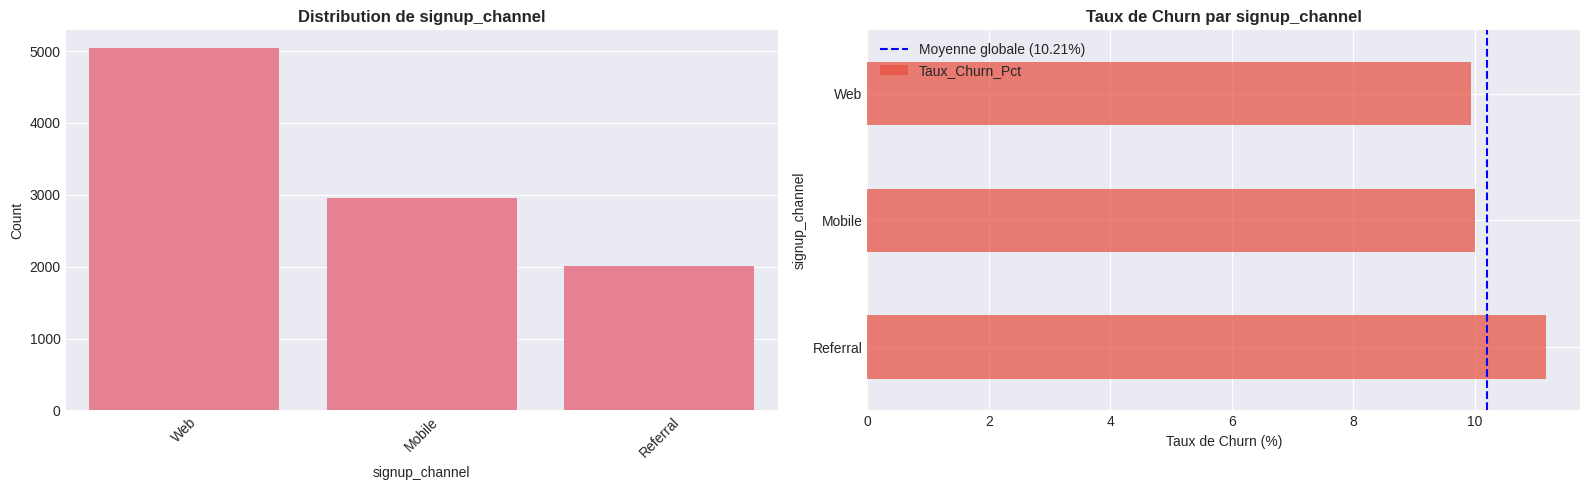

In [23]:
analyser_variable_categorielle("signup_channel")

Les clients s'inscrivent principalement via le canal `Web` (50%). Le canal `Referral` représente 20% des inscriptions, mais est associé à un **taux de `churn` plus élevé que la moyenne**.

ANALYSE DE LA VARIABLE: CONTRACT_TYPE

* Distribution générale:
               Count  Percentage
contract_type                   
Monthly         4967       49.67
Quarterly       3050       30.50
Yearly          1983       19.83

Nombre de catégories: 3

* Taux de churn par catégorie de contract_type:
               Churners  Total  Taux_Churn  Taux_Churn_Pct
contract_type                                             
Yearly              205   1983    0.103379       10.337872
Monthly             513   4967    0.103282       10.328166
Quarterly           303   3050    0.099344        9.934426

* Visualisation:


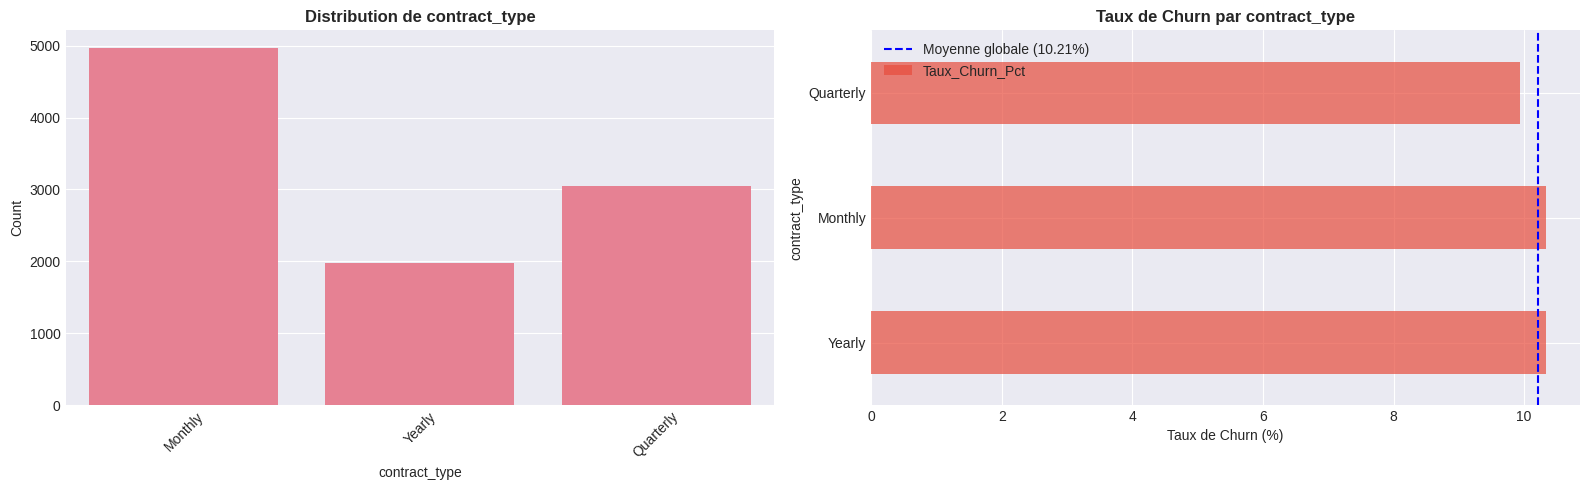

In [24]:
analyser_variable_categorielle("contract_type")

ANALYSE DE LA VARIABLE: PAYMENT_METHOD

* Distribution générale:
                Count  Percentage
payment_method                   
Card             5955       59.55
PayPal           2557       25.57
Bank Transfer    1488       14.88

Nombre de catégories: 3

* Taux de churn par catégorie de payment_method:
                Churners  Total  Taux_Churn  Taux_Churn_Pct
payment_method                                             
Card                 619   5955    0.103946       10.394626
PayPal               255   2557    0.099726        9.972624
Bank Transfer        147   1488    0.098790        9.879032

* Visualisation:


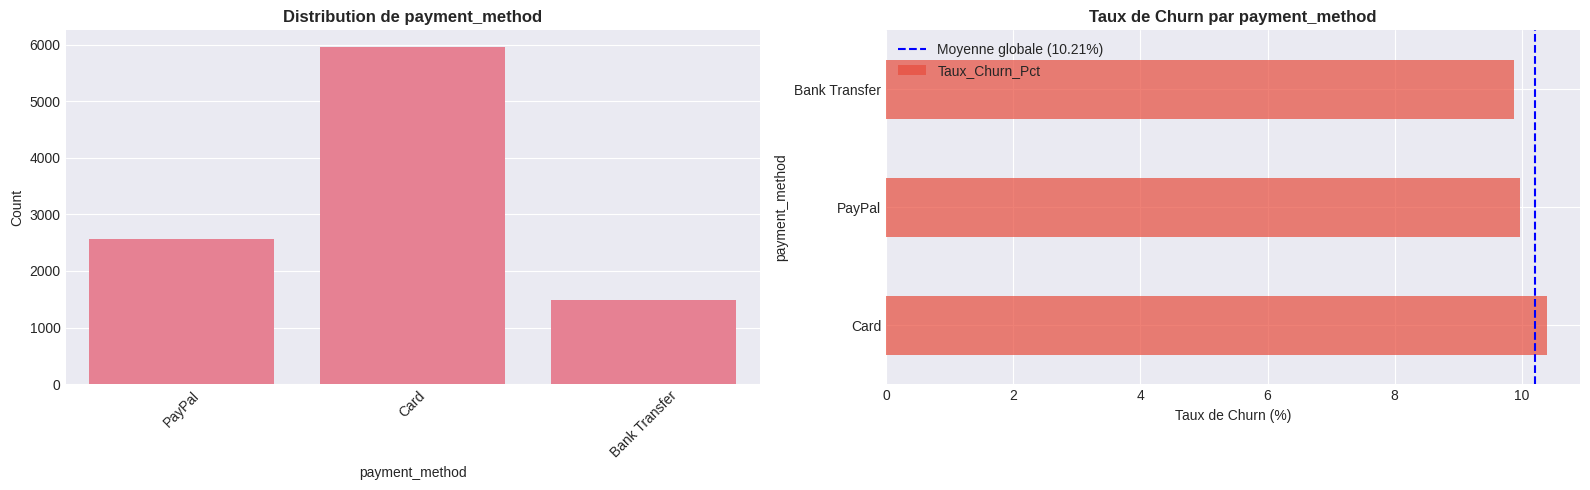

In [25]:
analyser_variable_categorielle("payment_method")

ANALYSE DE LA VARIABLE: DISCOUNT_APPLIED

* Distribution générale:
                  Count  Percentage
discount_applied                   
No                 6950        69.5
Yes                3050        30.5

Nombre de catégories: 2

* Taux de churn par catégorie de discount_applied:
                  Churners  Total  Taux_Churn  Taux_Churn_Pct
discount_applied                                             
No                     728   6950    0.104748       10.474820
Yes                    293   3050    0.096066        9.606557

* Visualisation:


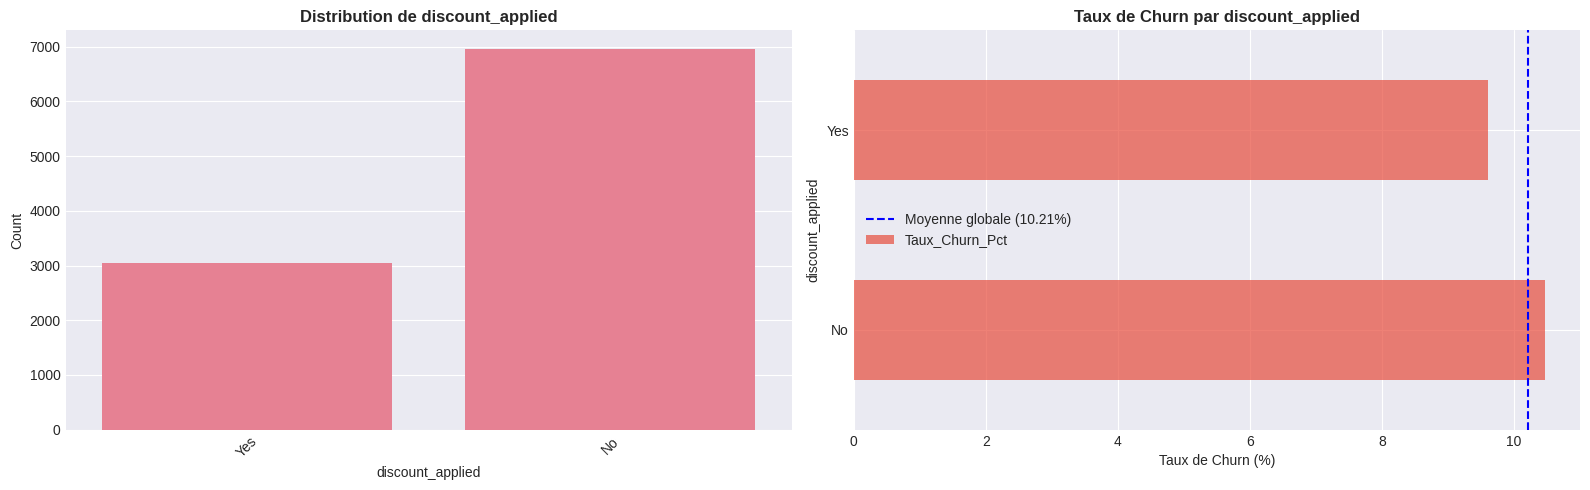

In [26]:
analyser_variable_categorielle("discount_applied")

La majorité (70%) des clients ne bénéficient pas d'une réduction. Cela influence légèrement le taux de `churn` qui est légèrement **plus élévé que la moyenne dans ce cas**.

ANALYSE DE LA VARIABLE: PRICE_INCREASE_LAST_3M

* Distribution générale:
                        Count  Percentage
price_increase_last_3m                   
No                       8055       80.55
Yes                      1945       19.45

Nombre de catégories: 2

* Taux de churn par catégorie de price_increase_last_3m:
                        Churners  Total  Taux_Churn  Taux_Churn_Pct
price_increase_last_3m                                             
Yes                          202   1945    0.103856       10.385604
No                           819   8055    0.101676       10.167598

* Visualisation:


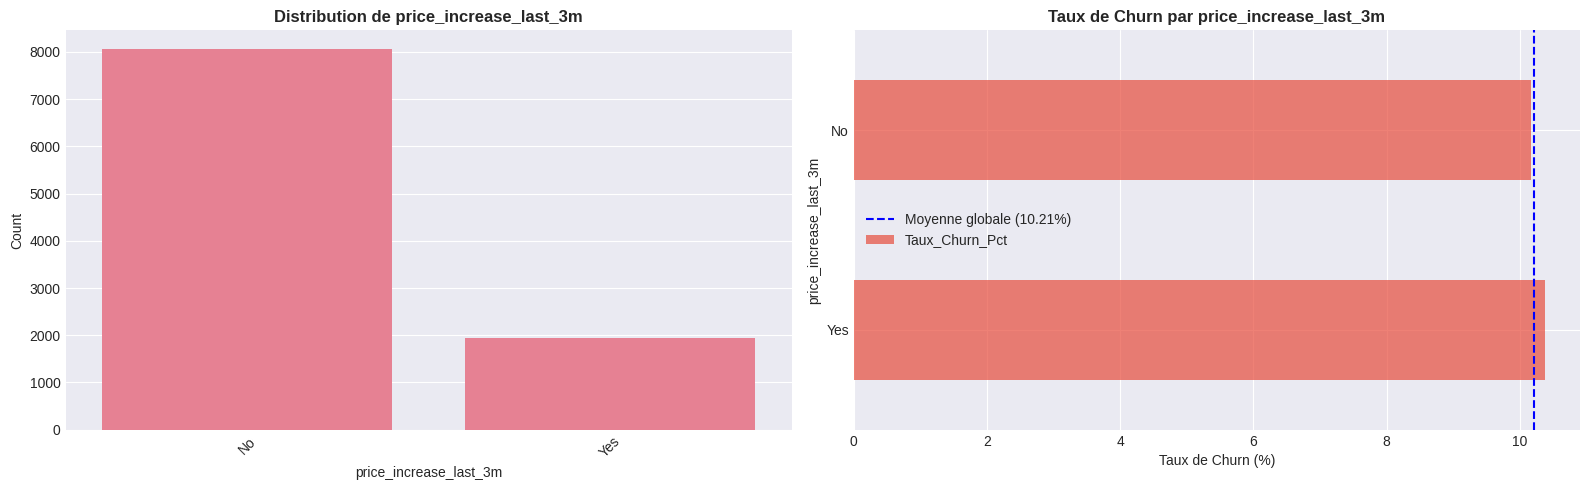

In [27]:
analyser_variable_categorielle("price_increase_last_3m")

80% des clients n'ont pas eu une augmentation du prix lors des 3 derrniers mois. Cela ne semble pas influencer significativement la rétention client.

ANALYSE DE LA VARIABLE: COMPLAINT_TYPE

* Distribution générale:
                Count  Percentage
complaint_type                   
Technical        3498   43.972344
Billing          2427   30.509114
Service          2030   25.518542

Nombre de catégories: 3

* Taux de churn par catégorie de complaint_type:
                Churners  Total  Taux_Churn  Taux_Churn_Pct
complaint_type                                             
Technical            361   3498    0.103202       10.320183
Billing              247   2427    0.101772       10.177173
Service              202   2030    0.099507        9.950739

* Visualisation:


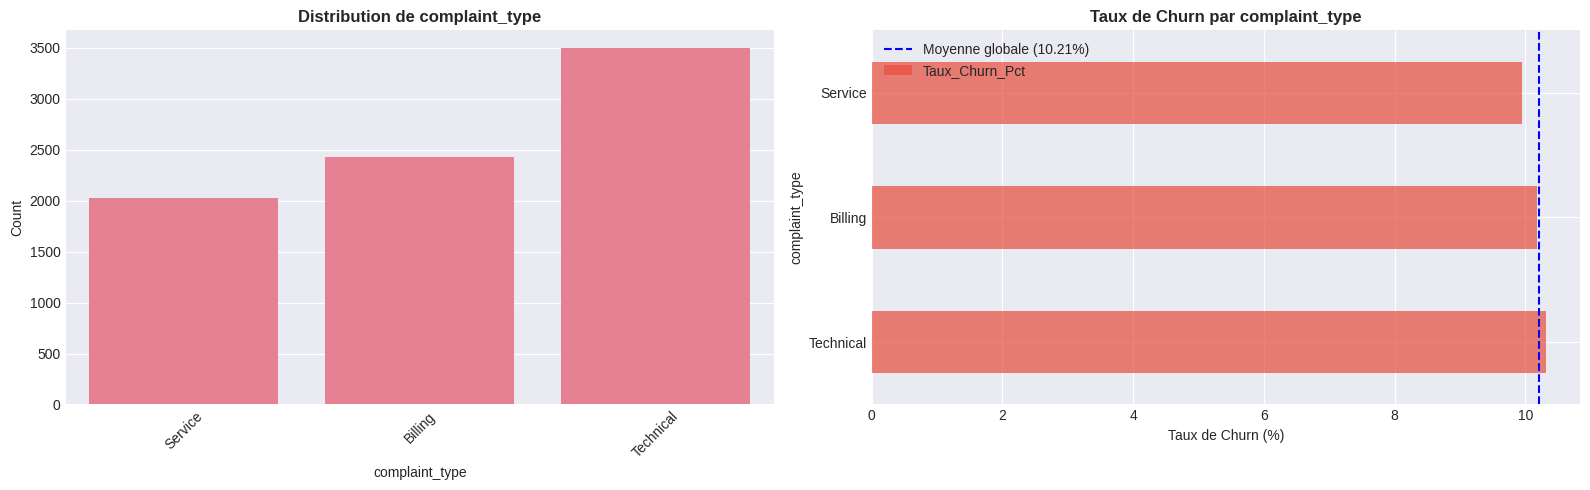

In [28]:
analyser_variable_categorielle("complaint_type")

ANALYSE DE LA VARIABLE: SURVEY_RESPONSE

* Distribution générale:
                 Count  Percentage
survey_response                   
Satisfied         4975       49.75
Neutral           2978       29.78
Unsatisfied       2047       20.47

Nombre de catégories: 3

* Taux de churn par catégorie de survey_response:
                 Churners  Total  Taux_Churn  Taux_Churn_Pct
survey_response                                             
Unsatisfied           228   2047    0.111383       11.138251
Satisfied             504   4975    0.101307       10.130653
Neutral               289   2978    0.097045        9.704500

* Visualisation:


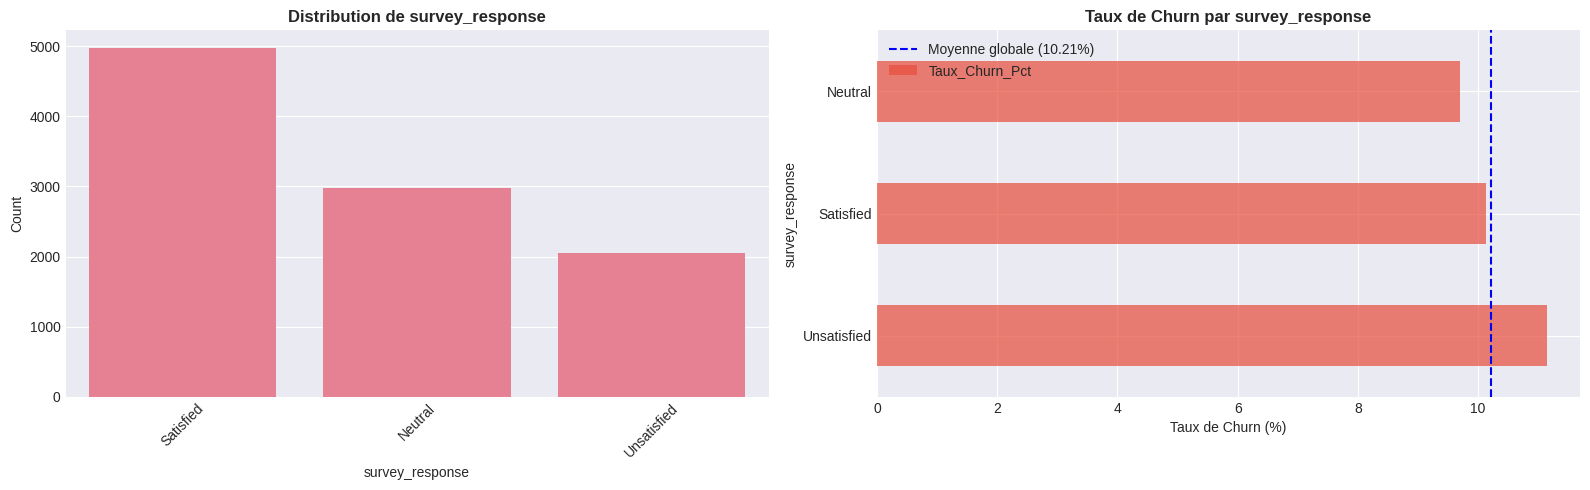

In [29]:
analyser_variable_categorielle("survey_response")

La majorité des clients sont satisfaits (50%). Les clients insatisfaits représentent 20% du dataset et sont associés à un **taux de `churn` plus élevé que la moyenne**.

---

### Mini conclusion EDA : Analyse des Variables Catégorielles

#### Variables à **faible pouvoir prédictif**

Les variables suivantes présentent des taux de churn relativement homogènes entre catégories :
- **`gender`**
- **`country`**
- **`contract_type`**
- **`payment_method`**
- **`complaint_type`**

Ces variables ne semble pas influencer significativement le taux de churn. Elles seront conservées dans la modélisation mais n'apporteront probablement qu'une contribution marginale.

### Variables à **pouvoir prédictif modéré**

Les variables suivantes montrent des **différences notables** de taux de churn entre catégories :

1. **`city`**
- **Observation** : Sur 7 villes, distribution plutôt uniforme globalement
- **Insight** : Taux de churn légèrement plus élevé pour New York, Toronto, Sydney
- **Taux plus bas** : Londres, Berlin
- **Hypothèse métier** : Différences culturelles, niveau de concurrence locale ou qualité du service régional

2. **`customer_segment`**
- **Distribution** : Individual (60%), SME (30%), Enterprise (10%)
- **Insight clé** : Le segment **SME** présente un taux de churn **supérieur à la moyenne**
- **Hypothèse métier** : Les PME ont des besoins spécifiques moins bien couverts ou sont plus sensibles au prix

3. **`signup_channel`**
- **Distribution** : Web (50%), Mobile (20%), Referral (20%), Other (10%)
- **Insight clé** : Le canal **Referral** est associé à un taux de churn **plus élevé**
- **Hypothèse métier** : Clients parrainés = moins d'engagement initial ou motivation extrinsèque (récompense)

4. **`discount_applied`**
- **Distribution** : 70% sans réduction, 30% avec réduction
- **Insight** : Les clients **sans réduction** ont un taux de churn **légèrement plus élevé**
- **Hypothèse métier** : Les réductions fidélisent temporairement, ou les clients avec réduction sont déjà identifiés comme à risque

5. **`survey_response`**
- **Distribution** : Satisfied (50%), Neutral (30%), Unsatisfied (20%)
- **Insight clé** : Les clients **insatisfaits** présentent un taux de churn **nettement supérieur**
- **Hypothèse métier** : La satisfaction est un indicateur précoce du churn (variable fortement corrélée)

### Variables peu discriminantes
- **`price_increase_last_3m`** : 80% sans augmentation, mais impact limité sur le churn
  - Conclusion : Les augmentations de prix récentes ne semblent **pas** être un facteur majeur de résiliation


## Analyse des variables numériques

In [30]:
def analyser_variable_numerique(variable):
    """Analyse complète d'une variable numérique par rapport au churn."""
    print(f"ANALYSE DE LA VARIABLE: {variable.upper()}")
    
    # 1. Statistiques descriptives
    print("\n* Statistiques descriptives:")
    print(df[variable].describe())
    
    # 2. Comparaison par groupe de churn
    print(f"\n* Statistiques par groupe:")
    stats_by_churn = df.groupby('churn')[variable].describe()
    print(stats_by_churn)
    
    # Mediane par groupe
    mediane_fideles = df[df['churn'] == 0][variable].median()
    mediane_partis = df[df['churn'] == 1][variable].median()
    print(f"\nMediane clients fideles: {mediane_fideles:.2f}")
    print(f"Mediane clients partis: {mediane_partis:.2f}")
    print(f"Ecart: {abs(mediane_partis - mediane_fideles):.2f}")
    
    # 3. Visualisations
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    
    # Distribution globale - Histogramme avec KDE
    sns.histplot(data=df, x=variable, bins=30, kde=True, ax=axes[0, 0], color='steelblue')
    axes[0, 0].set_title(f'Distribution de {variable}', fontsize=12)
    axes[0, 0].set_xlabel(variable)
    axes[0, 0].set_ylabel('Frequence')
    axes[0, 0].grid(alpha=0.3)
    
    # Distribution globale - Boxplot
    sns.boxplot(data=df, y=variable, ax=axes[0, 1], color='steelblue')
    axes[0, 1].set_title(f'Boxplot de {variable}', fontsize=12)
    axes[0, 1].set_ylabel(variable)
    axes[0, 1].grid(alpha=0.3)
    
    # Distribution par churn - Boxplot
    sns.boxplot(data=df, x='churn', y=variable, ax=axes[1, 0])
    axes[1, 0].set_title(f'Distribution de {variable} par churn', fontsize=12)
    axes[1, 0].set_xlabel('Churn')
    axes[1, 0].set_ylabel(variable)
    axes[1, 0].set_xticks([0, 1])
    axes[1, 0].set_xticklabels(['Fidele (0)', 'Parti (1)'])
    axes[1, 0].grid(alpha=0.3)
    
    # Distribution par churn - Histogramme avec KDE
    sns.histplot(data=df, x=variable, hue='churn', bins=30, kde=True, alpha=0.6, ax=axes[1, 1])
    axes[1, 1].set_title(f'Distribution de {variable} par churn', fontsize=12)
    axes[1, 1].set_xlabel(variable)
    axes[1, 1].set_ylabel('Frequence')
    axes[1, 1].legend(labels=['Fidele (0)', 'Parti (1)'])
    axes[1, 1].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(IMG_PATH / f"eda_numerique_{variable}.png")
    plt.show()

ANALYSE DE LA VARIABLE: AGE

* Statistiques descriptives:
count    10000.000000
mean        45.906100
std         16.420416
min         18.000000
25%         32.000000
50%         46.000000
75%         60.000000
max         74.000000
Name: age, dtype: float64

* Statistiques par groupe:
        count       mean        std   min   25%   50%   75%   max
churn                                                            
0      8979.0  45.849872  16.416362  18.0  32.0  45.0  60.0  74.0
1      1021.0  46.400588  16.455798  18.0  33.0  46.0  61.0  74.0

Mediane clients fideles: 45.00
Mediane clients partis: 46.00
Ecart: 1.00


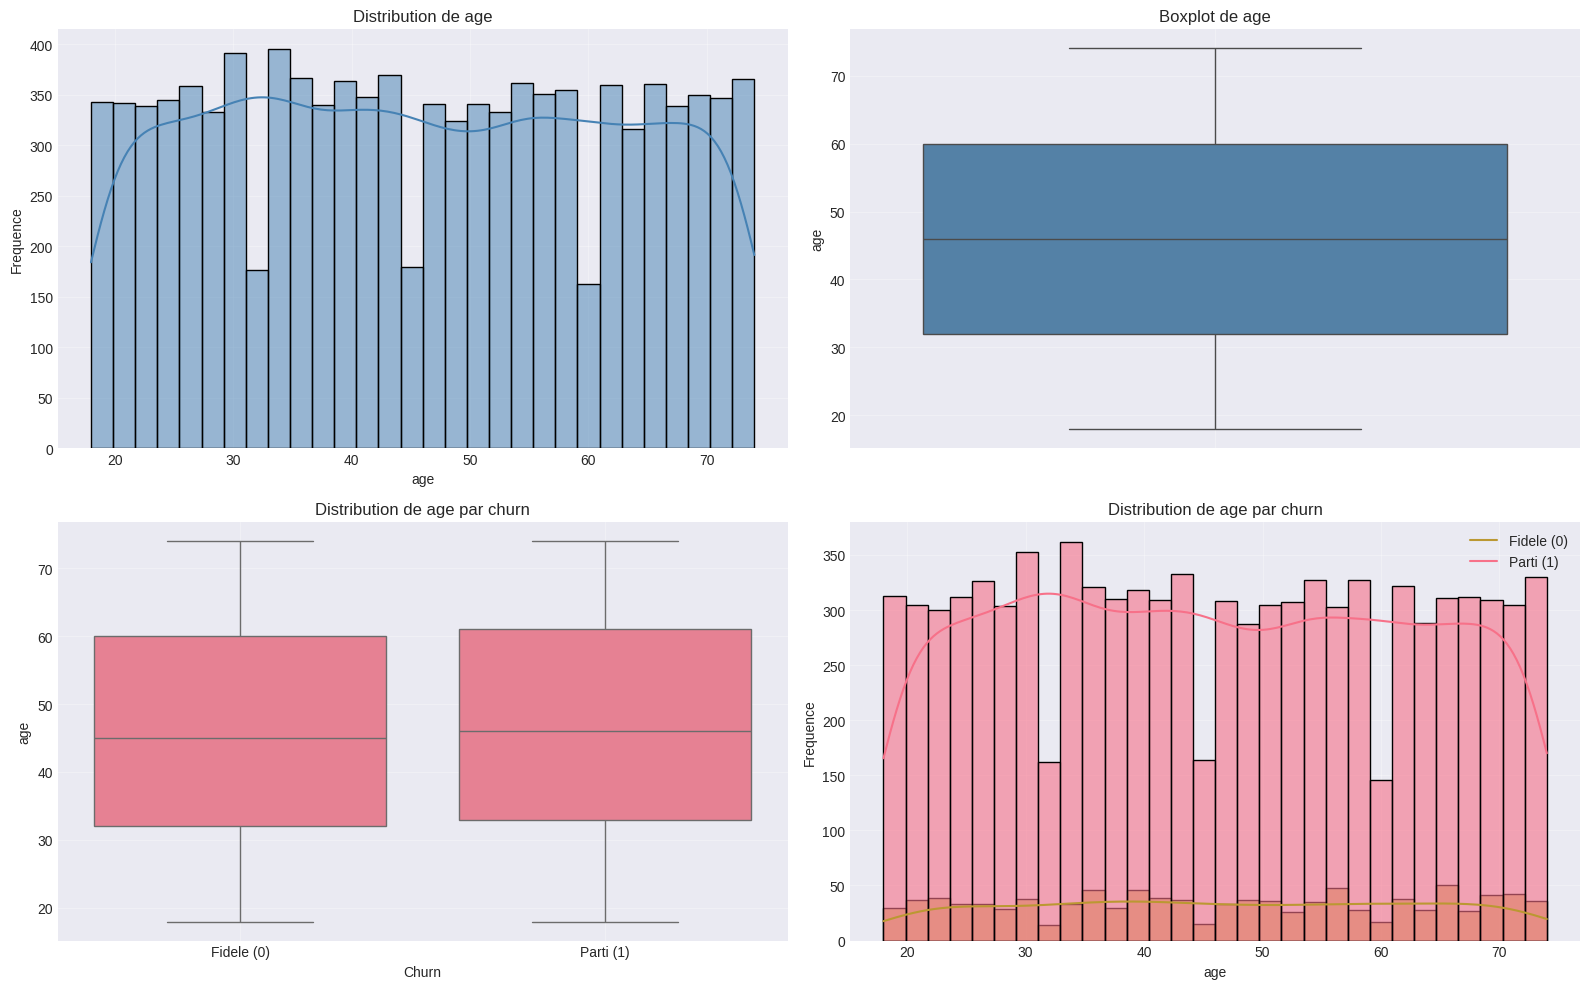

In [31]:
analyser_variable_numerique('age')

ANALYSE DE LA VARIABLE: TENURE_MONTHS

* Statistiques descriptives:
count    10000.000000
mean        30.155700
std         17.099517
min          1.000000
25%         16.000000
50%         30.000000
75%         45.000000
max         59.000000
Name: tenure_months, dtype: float64

* Statistiques par groupe:
        count       mean        std  min   25%   50%   75%   max
churn                                                           
0      8979.0  30.830382  16.763834  1.0  17.0  31.0  45.0  59.0
1      1021.0  24.222331  18.801297  1.0   5.0  22.0  41.0  59.0

Mediane clients fideles: 31.00
Mediane clients partis: 22.00
Ecart: 9.00


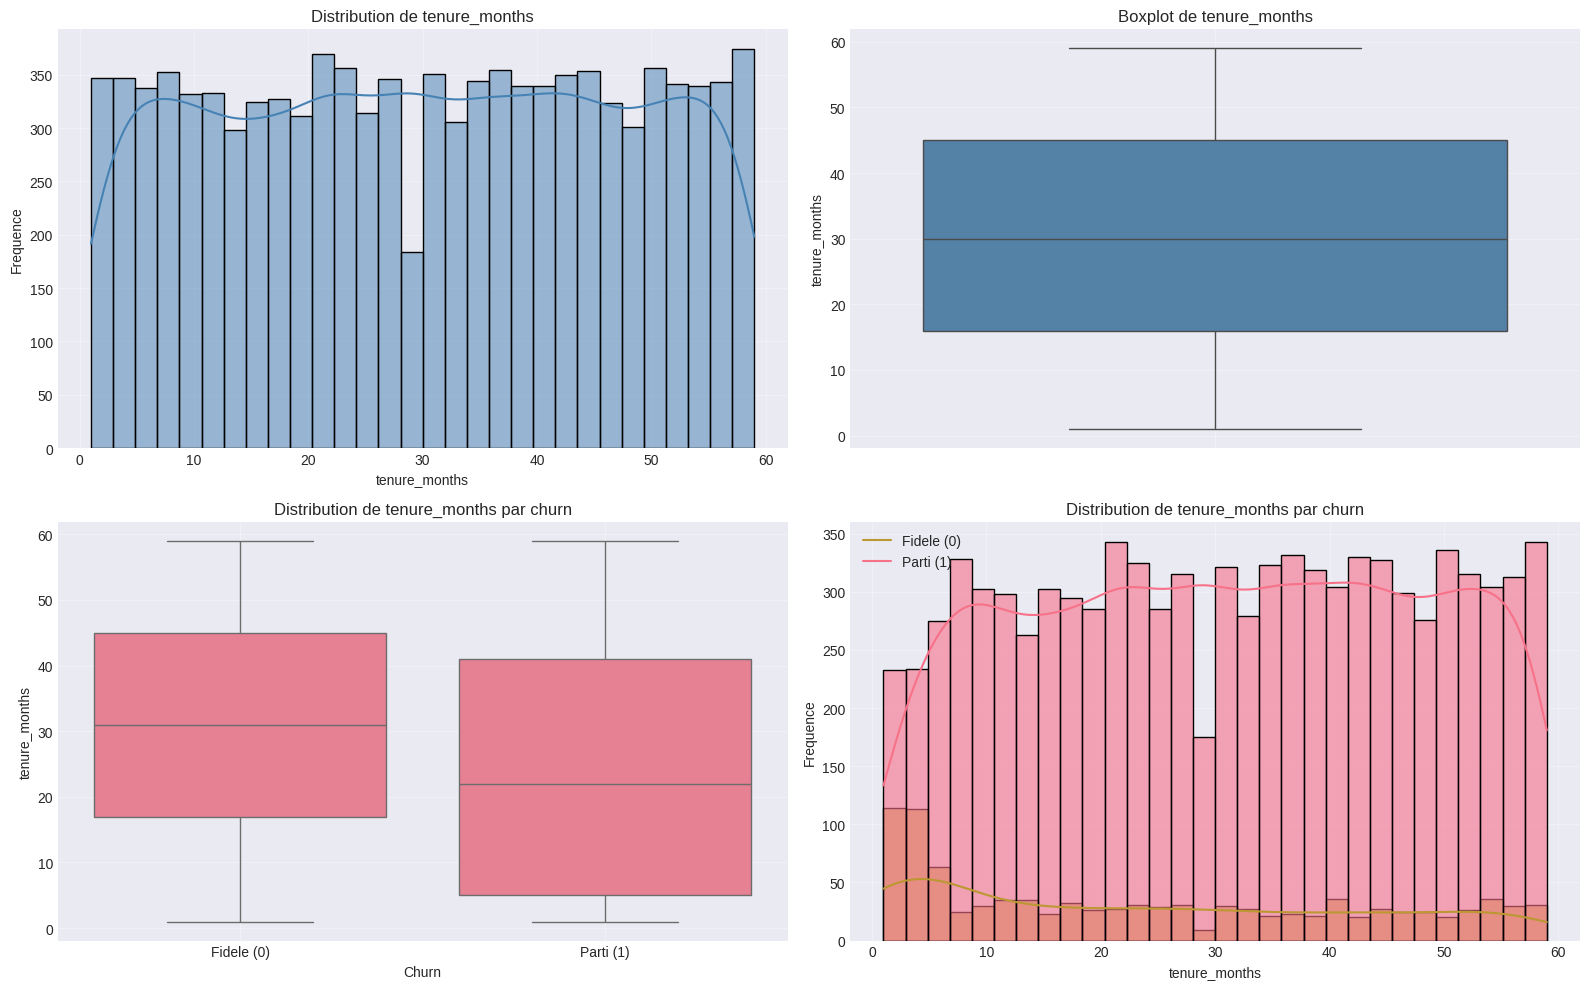

In [32]:
analyser_variable_numerique('tenure_months')

**Variable fortement discriminante** : les clients partis ont une ancienneté médiane de 22 mois contre 31 mois pour les fidèles (écart de 9 mois). Les nouveaux clients semblent plus à risque de churn.

ANALYSE DE LA VARIABLE: MONTHLY_LOGINS

* Statistiques descriptives:
count    10000.000000
mean        19.672000
std          9.838003
min          0.000000
25%         13.000000
50%         20.000000
75%         26.000000
max         54.000000
Name: monthly_logins, dtype: float64

* Statistiques par groupe:
        count       mean        std  min   25%   50%   75%   max
churn                                                           
0      8979.0  19.998218   9.662401  0.0  13.0  20.0  27.0  54.0
1      1021.0  16.803134  10.855713  0.0   8.0  17.0  24.0  51.0

Mediane clients fideles: 20.00
Mediane clients partis: 17.00
Ecart: 3.00


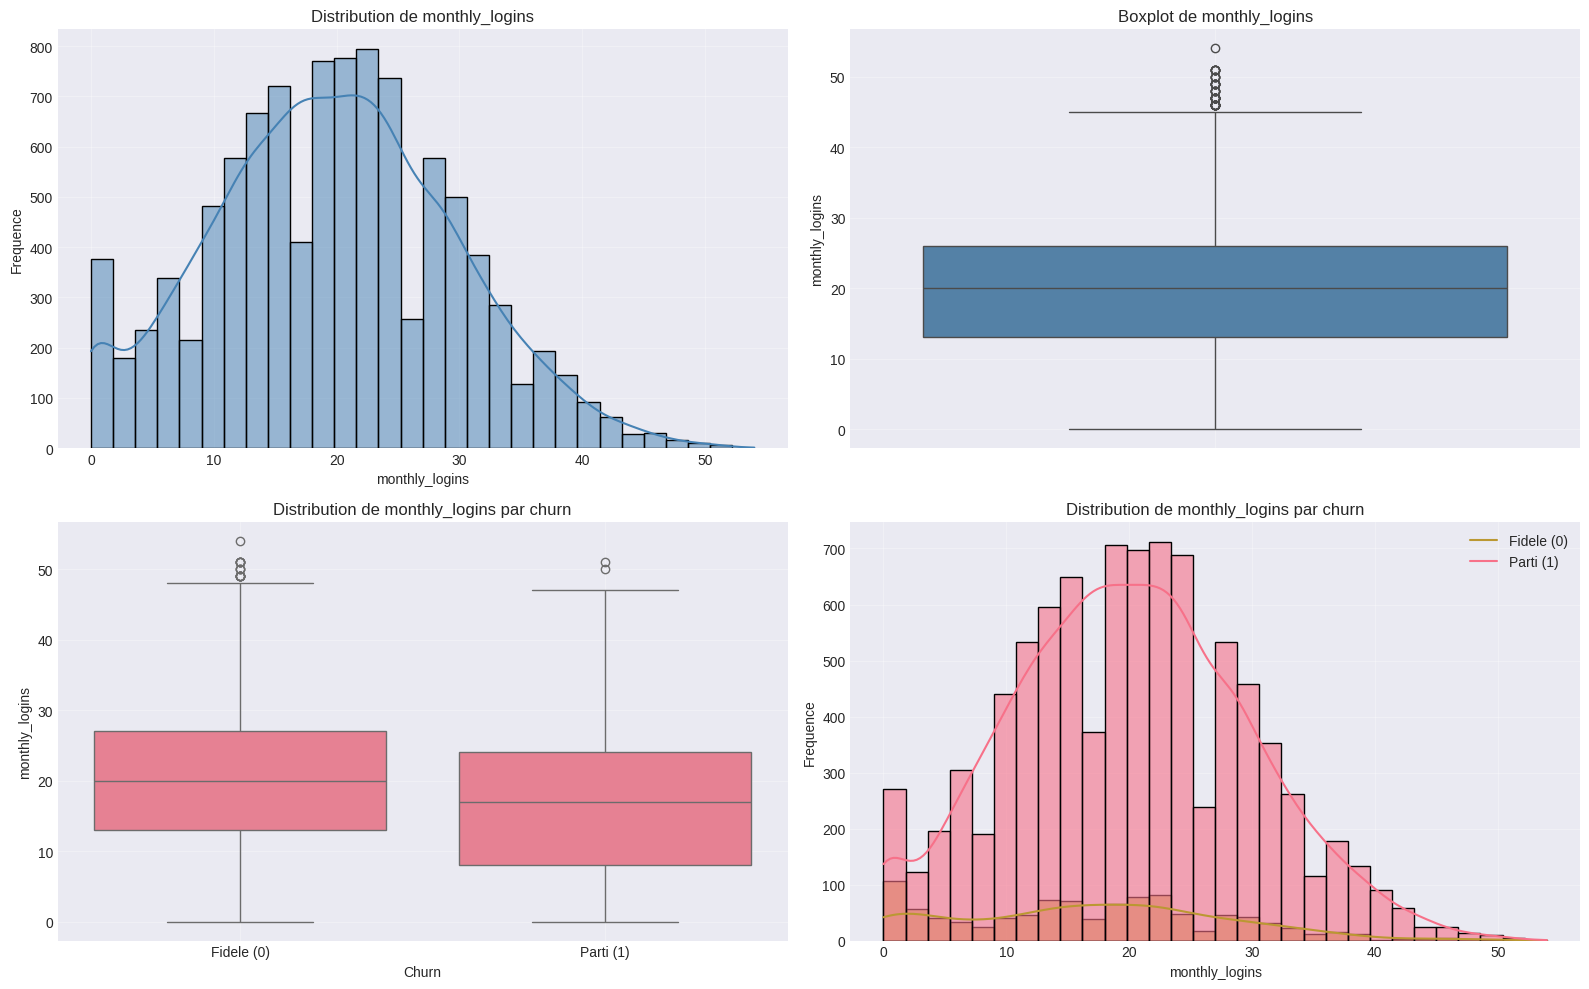

In [33]:
analyser_variable_numerique('monthly_logins')

Cette variable semble influencer le `churn` : la médiane de la variable `monthly_logins` est plus faible chez les clients partis que chez les clients fidèles

ANALYSE DE LA VARIABLE: WEEKLY_ACTIVE_DAYS

* Statistiques descriptives:
count    10000.000000
mean         3.479400
std          2.302283
min          0.000000
25%          1.000000
50%          3.000000
75%          5.000000
max          7.000000
Name: weekly_active_days, dtype: float64

* Statistiques par groupe:
        count      mean       std  min  25%  50%  75%  max
churn                                                     
0      8979.0  3.486246  2.298484  0.0  1.0  3.0  5.0  7.0
1      1021.0  3.419197  2.335696  0.0  1.0  3.0  5.0  7.0

Mediane clients fideles: 3.00
Mediane clients partis: 3.00
Ecart: 0.00


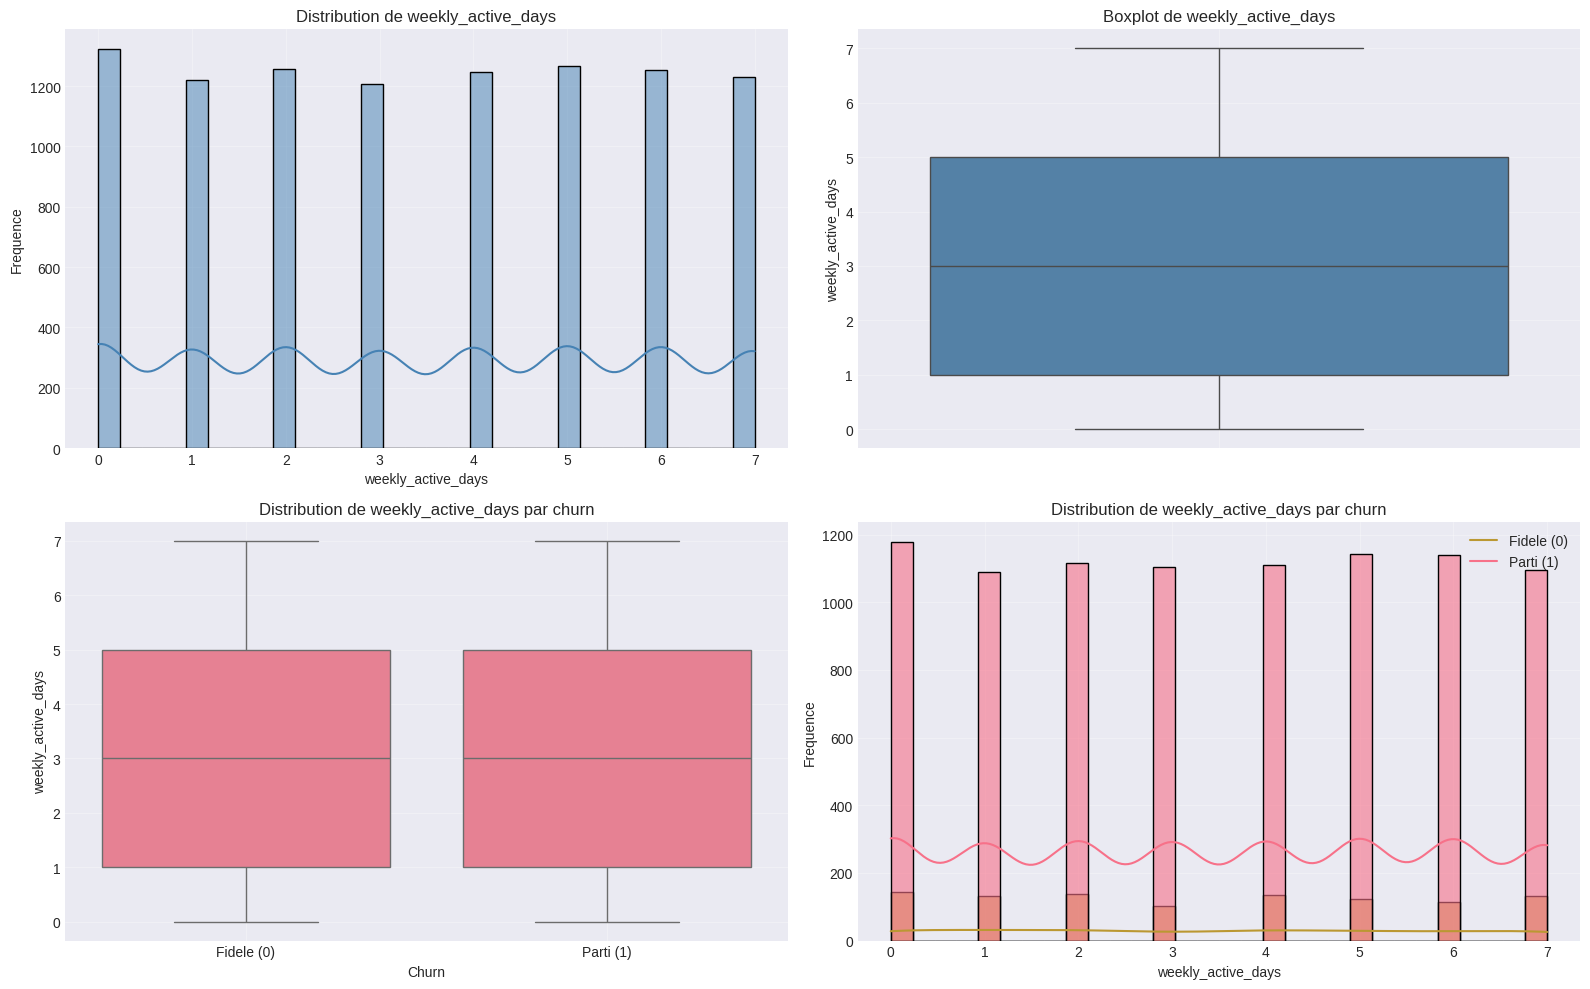

In [34]:
analyser_variable_numerique('weekly_active_days')

ANALYSE DE LA VARIABLE: AVG_SESSION_TIME

* Statistiques descriptives:
count    10000.000000
mean        15.187890
std          6.830774
min          1.000000
25%         10.391645
50%         15.161659
75%         19.882034
max         41.996411
Name: avg_session_time, dtype: float64

* Statistiques par groupe:
        count       mean       std  min        25%        50%        75%  \
churn                                                                      
0      8979.0  15.198622  6.857705  1.0  10.385720  15.214540  19.873171   
1      1021.0  15.093508  6.591697  1.0  10.447476  14.753454  20.018344   

             max  
churn             
0      41.996411  
1      36.128637  

Mediane clients fideles: 15.21
Mediane clients partis: 14.75
Ecart: 0.46


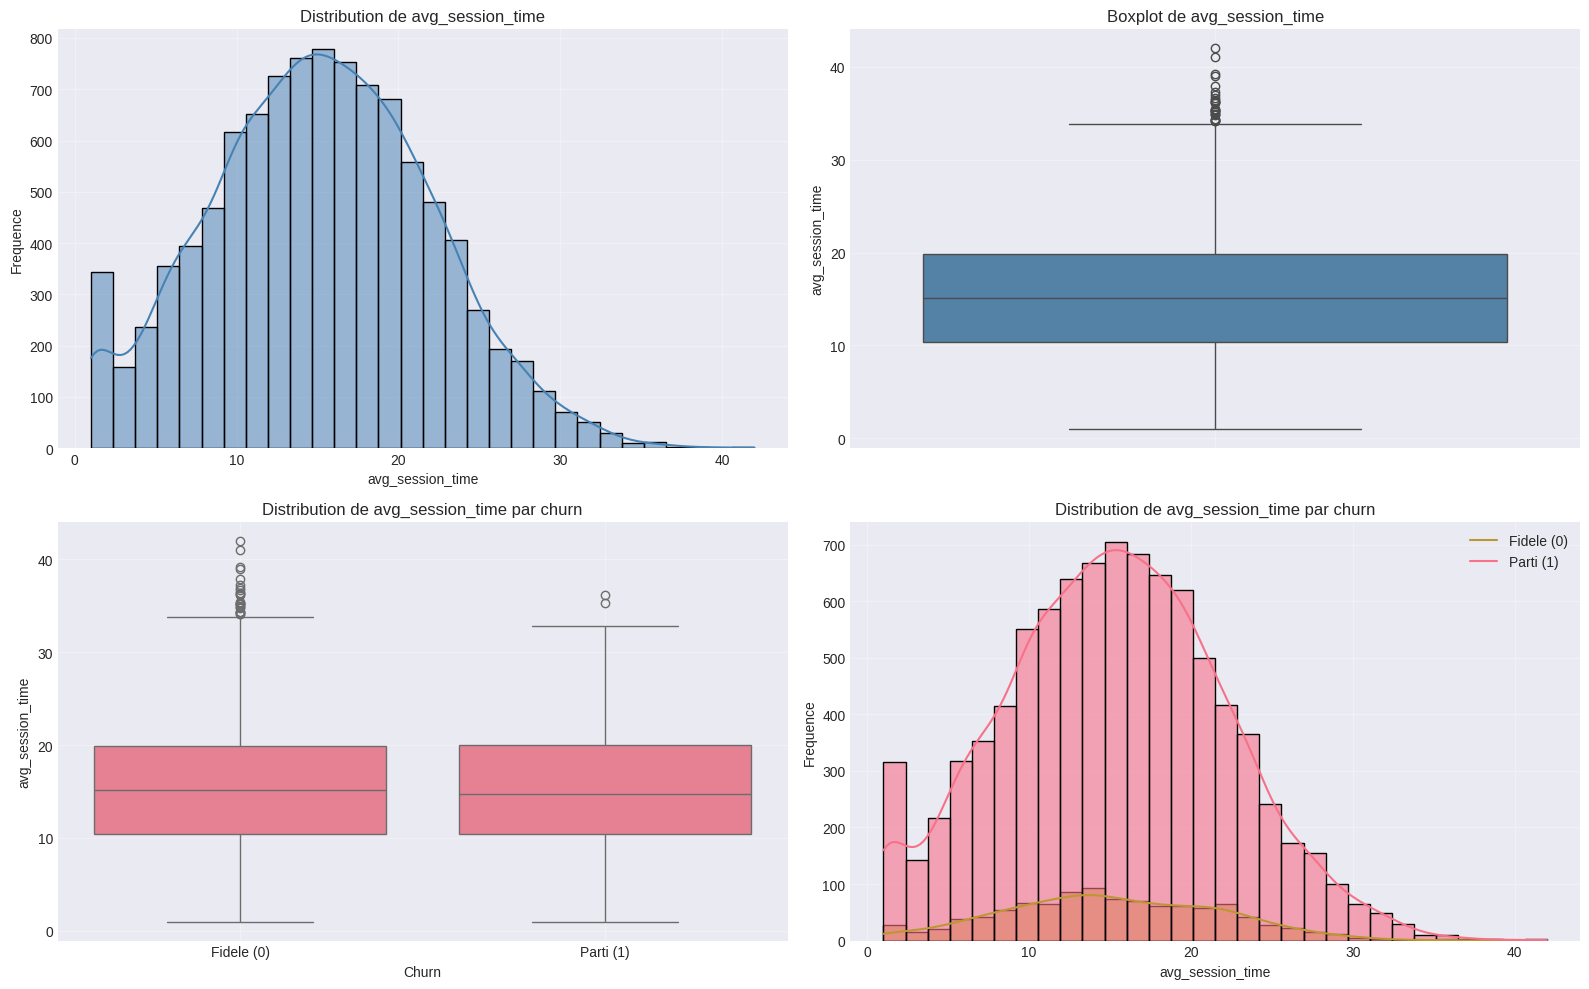

In [35]:
analyser_variable_numerique('avg_session_time')

ANALYSE DE LA VARIABLE: FEATURES_USED

* Statistiques descriptives:
count    10000.000000
mean         4.990800
std          2.211607
min          1.000000
25%          3.000000
50%          5.000000
75%          6.000000
max         15.000000
Name: features_used, dtype: float64

* Statistiques par groupe:
        count      mean       std  min  25%  50%  75%   max
churn                                                      
0      8979.0  4.986747  2.209042  1.0  3.0  5.0  6.0  14.0
1      1021.0  5.026445  2.234815  1.0  3.0  5.0  6.0  15.0

Mediane clients fideles: 5.00
Mediane clients partis: 5.00
Ecart: 0.00


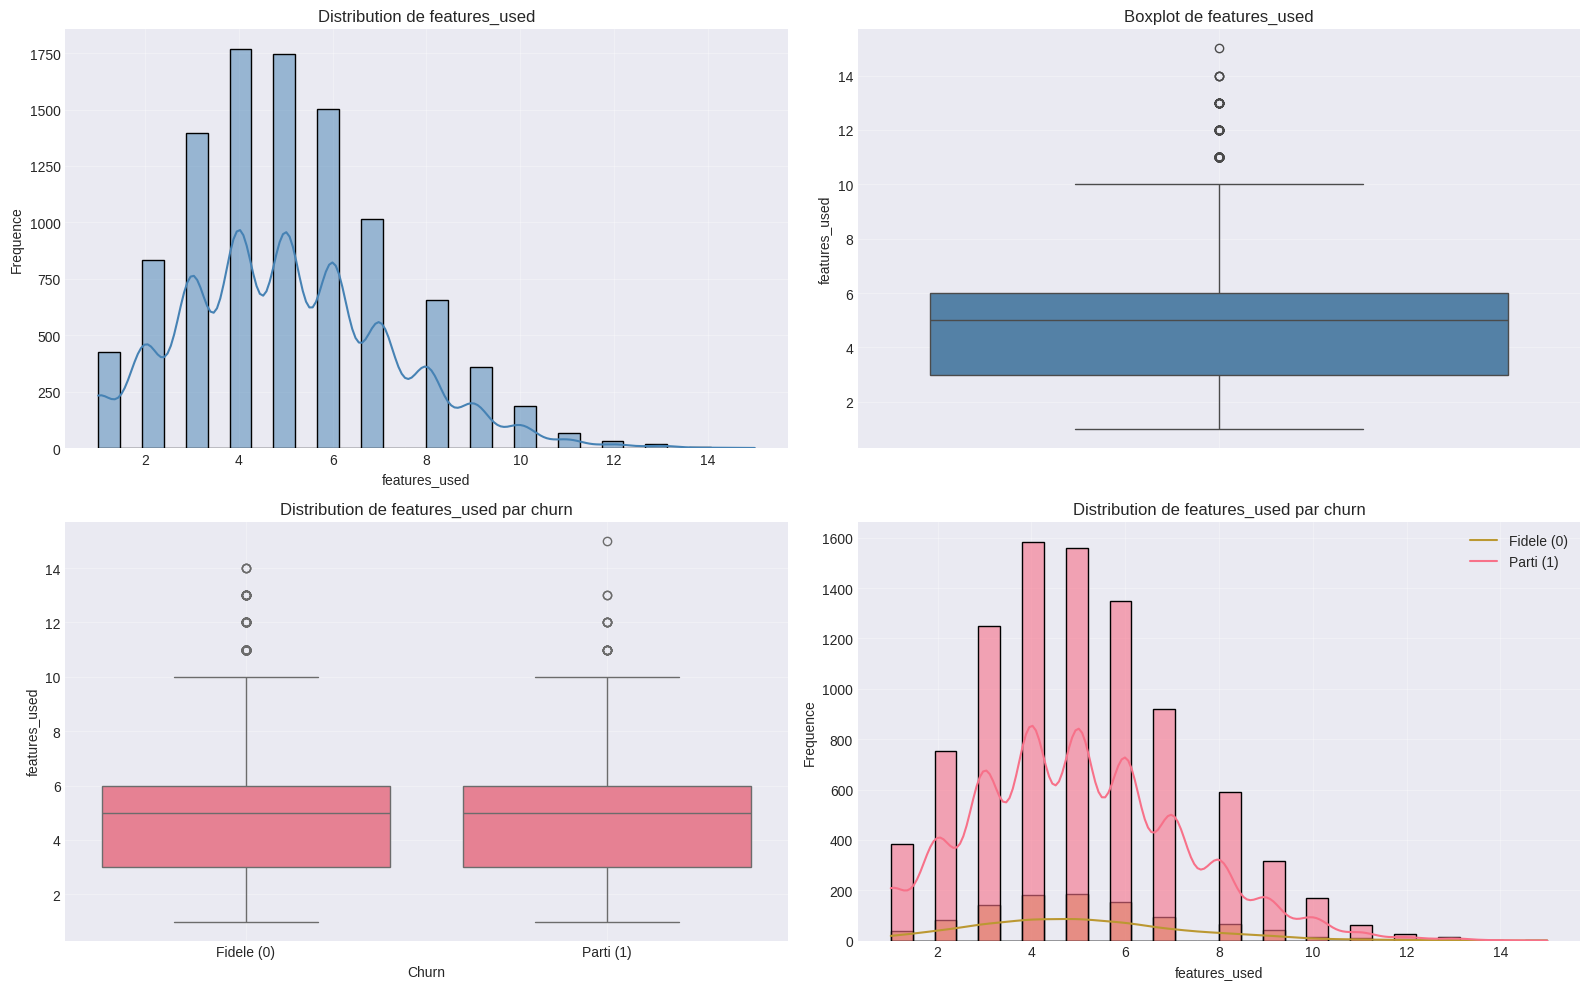

In [36]:
analyser_variable_numerique('features_used')

ANALYSE DE LA VARIABLE: USAGE_GROWTH_RATE

* Statistiques descriptives:
count    10000.000000
mean         0.019423
std          0.149567
min         -0.580000
25%         -0.080000
50%          0.020000
75%          0.120000
max          0.540000
Name: usage_growth_rate, dtype: float64

* Statistiques par groupe:
        count      mean       std   min   25%   50%   75%   max
churn                                                          
0      8979.0  0.019157  0.149806 -0.58 -0.08  0.02  0.12  0.53
1      1021.0  0.021763  0.147502 -0.46 -0.07  0.02  0.12  0.54

Mediane clients fideles: 0.02
Mediane clients partis: 0.02
Ecart: 0.00


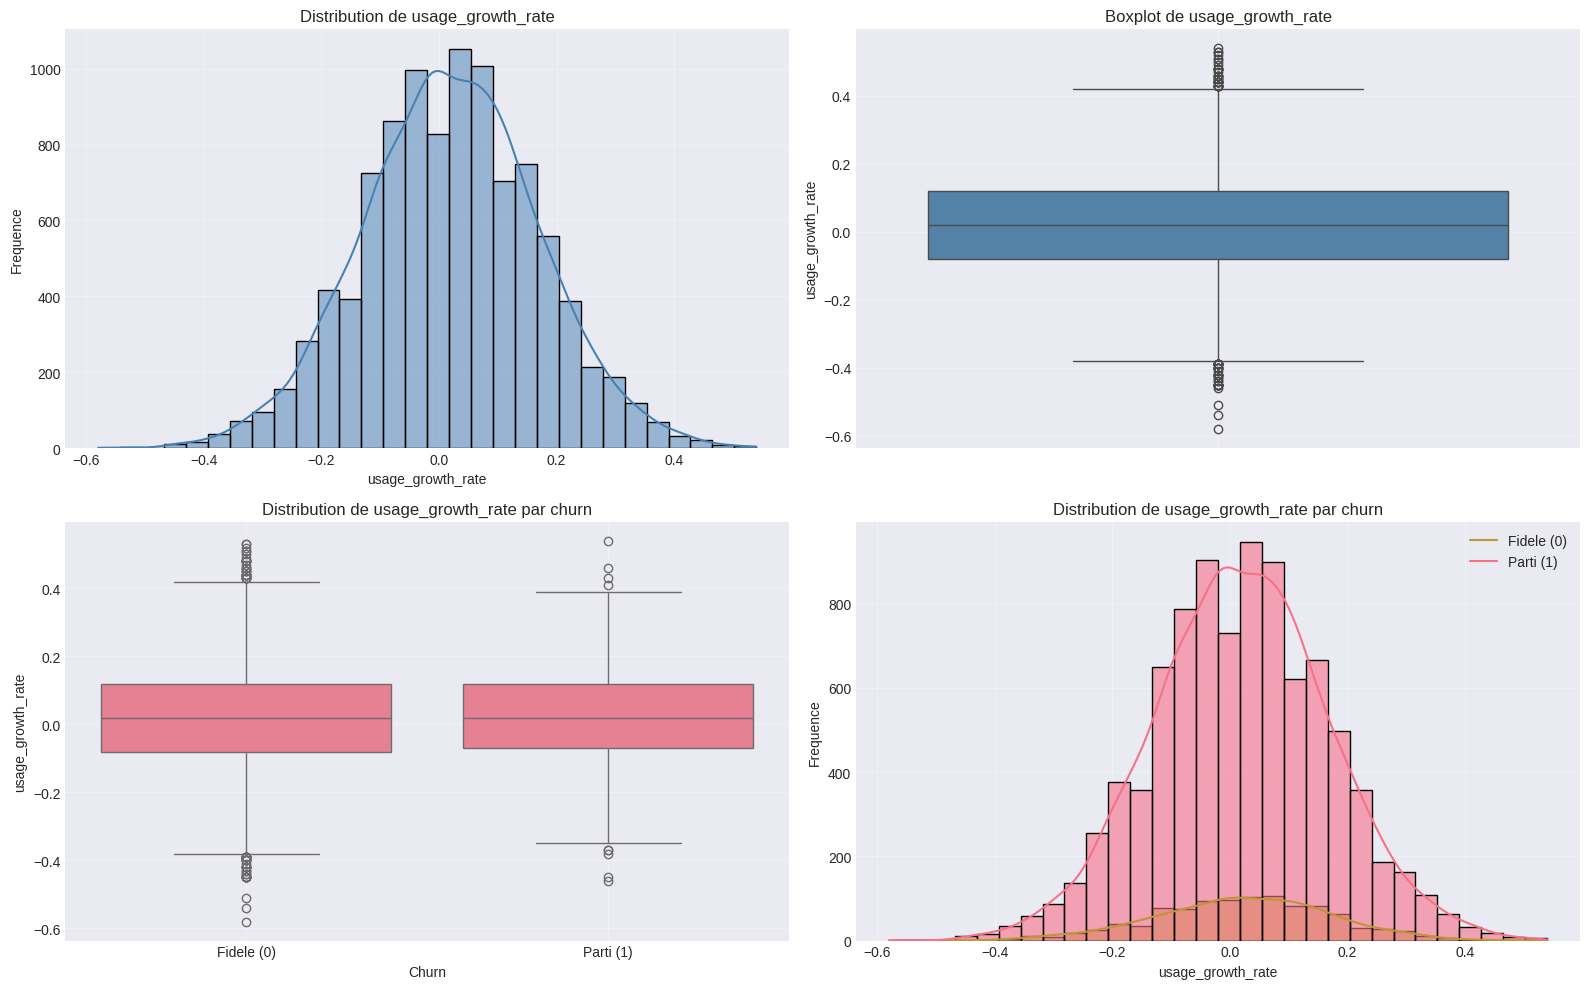

In [37]:
analyser_variable_numerique('usage_growth_rate')

ANALYSE DE LA VARIABLE: LAST_LOGIN_DAYS_AGO

* Statistiques descriptives:
count    10000.000000
mean         9.505200
std          9.799417
min          0.000000
25%          2.000000
50%          6.000000
75%         13.000000
max         80.000000
Name: last_login_days_ago, dtype: float64

* Statistiques par groupe:
        count       mean        std  min  25%  50%   75%   max
churn                                                         
0      8979.0   9.382114   9.570447  0.0  2.0  6.0  13.0  78.0
1      1021.0  10.587659  11.569543  0.0  2.0  7.0  14.0  80.0

Mediane clients fideles: 6.00
Mediane clients partis: 7.00
Ecart: 1.00


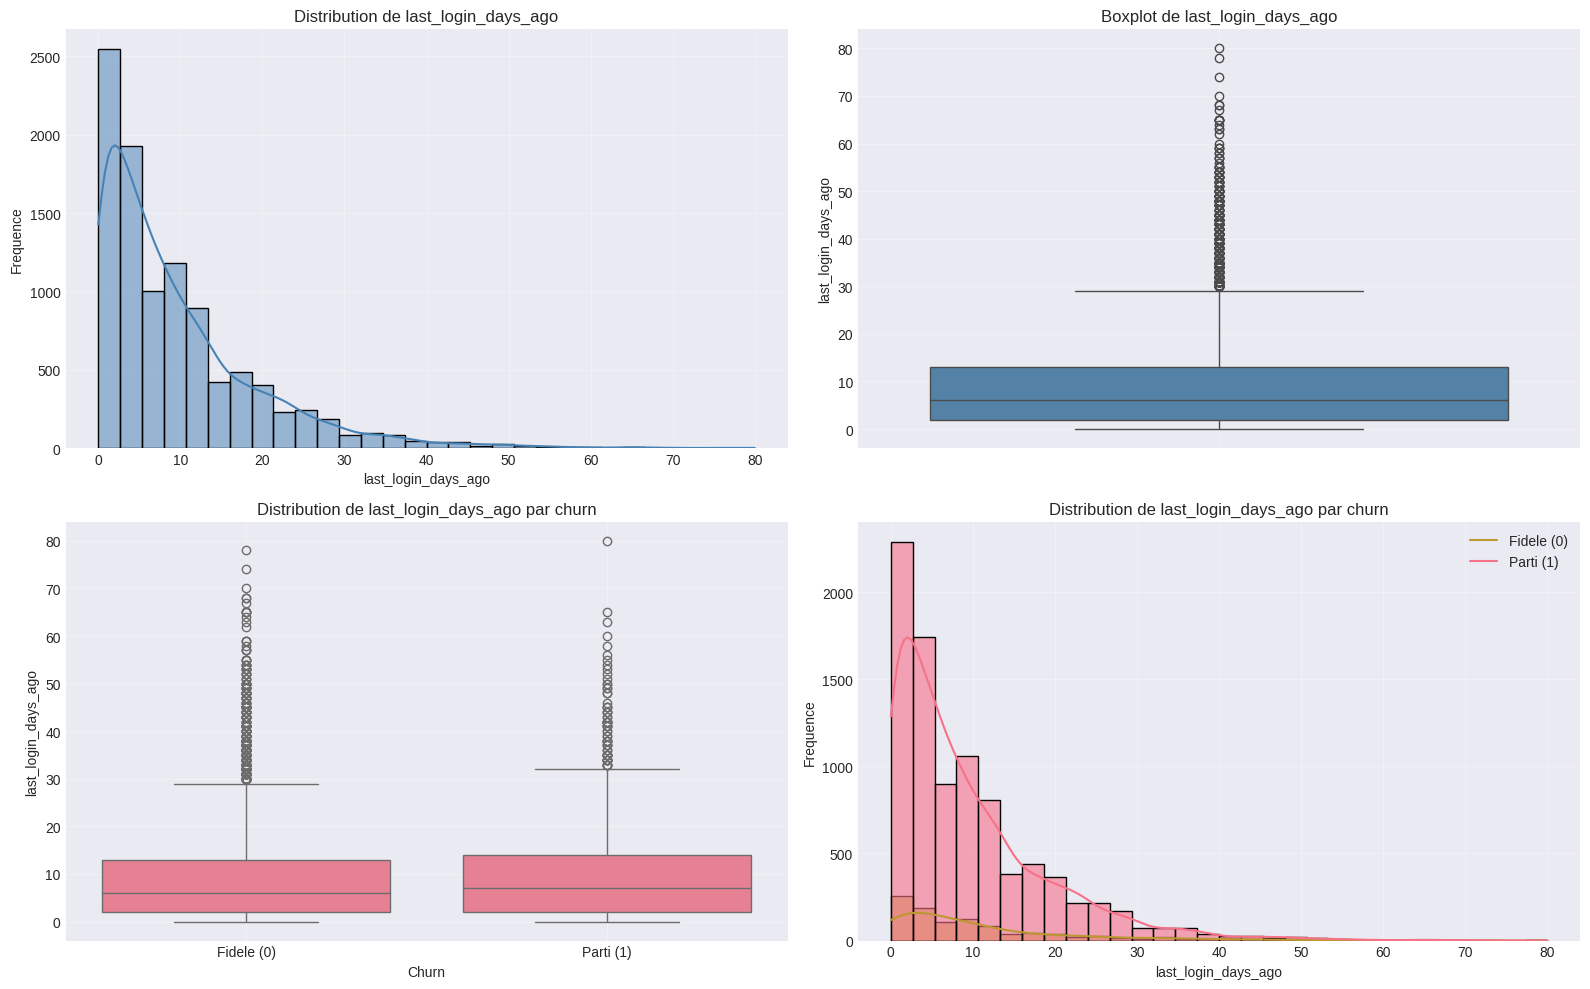

In [38]:
analyser_variable_numerique('last_login_days_ago')

ANALYSE DE LA VARIABLE: MONTHLY_FEE

* Statistiques descriptives:
count    10000.000000
mean        34.930000
std         23.785115
min         10.000000
25%         20.000000
50%         30.000000
75%         50.000000
max        100.000000
Name: monthly_fee, dtype: float64

* Statistiques par groupe:
        count       mean        std   min   25%   50%   75%    max
churn                                                             
0      8979.0  34.970487  23.804139  10.0  20.0  30.0  50.0  100.0
1      1021.0  34.573947  23.625752  10.0  20.0  30.0  50.0  100.0

Mediane clients fideles: 30.00
Mediane clients partis: 30.00
Ecart: 0.00


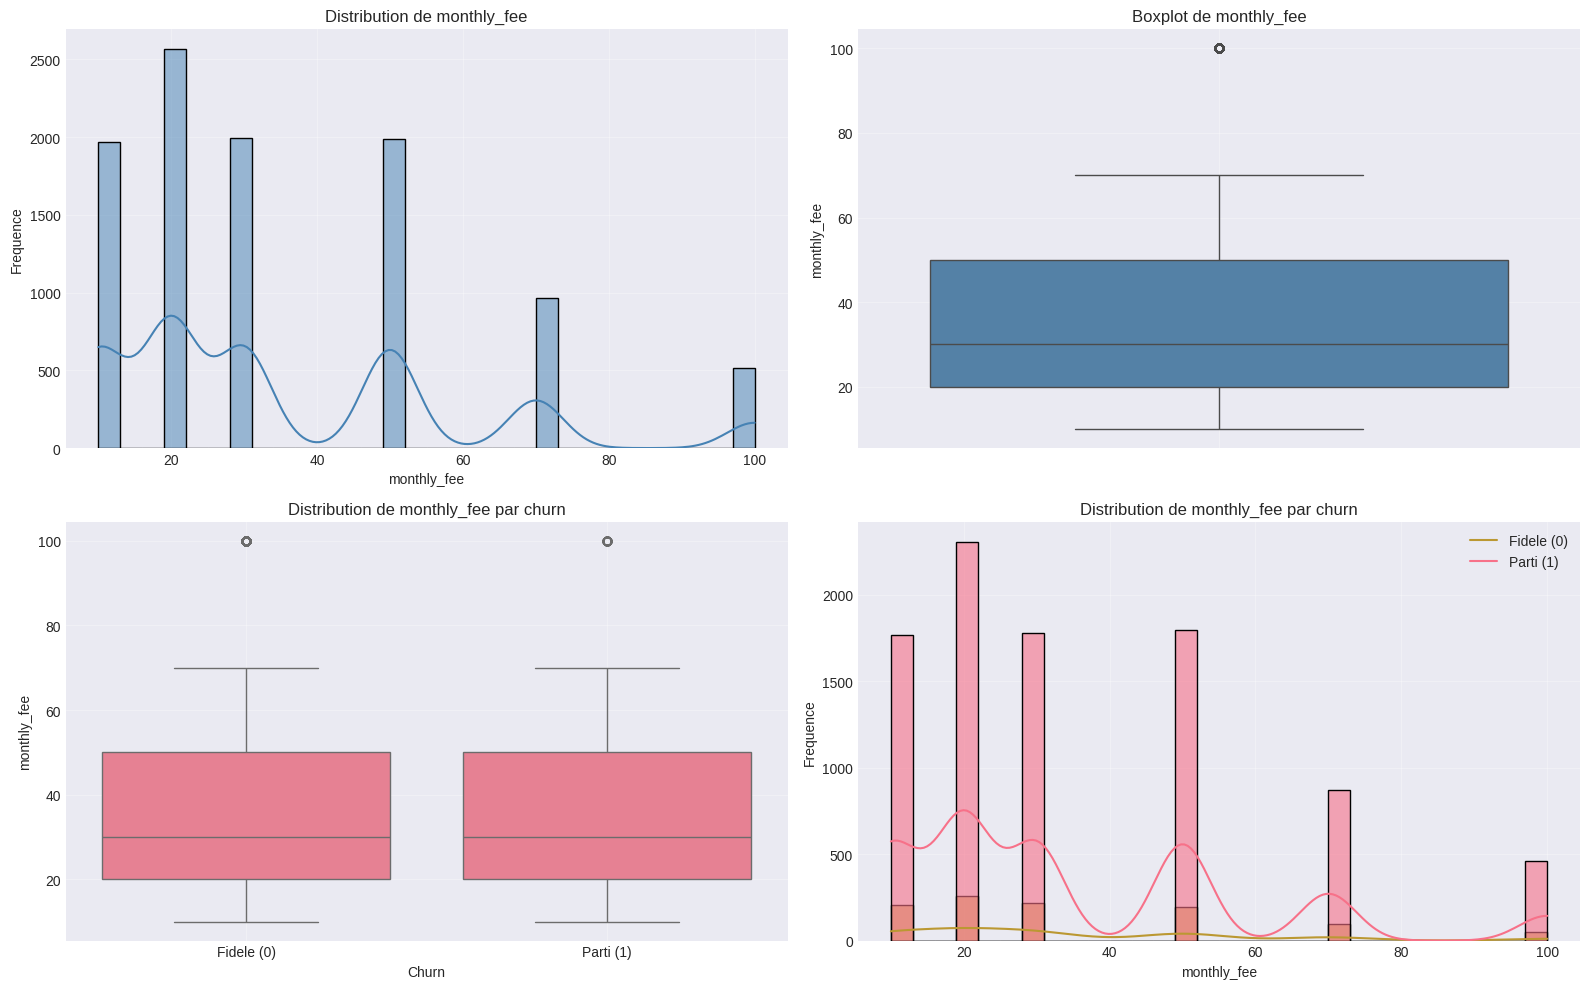

In [39]:
analyser_variable_numerique('monthly_fee')

ANALYSE DE LA VARIABLE: TOTAL_REVENUE

* Statistiques descriptives:
count    10000.000000
mean      1057.018000
std       1020.148233
min         10.000000
25%        340.000000
50%        720.000000
75%       1440.000000
max       5900.000000
Name: total_revenue, dtype: float64

* Statistiques par groupe:
        count         mean          std   min    25%    50%     75%     max
churn                                                                      
0      8979.0  1081.138211  1021.901822  10.0  360.0  750.0  1470.0  5900.0
1      1021.0   844.897160   979.817767  10.0  150.0  490.0  1140.0  5500.0

Mediane clients fideles: 750.00
Mediane clients partis: 490.00
Ecart: 260.00


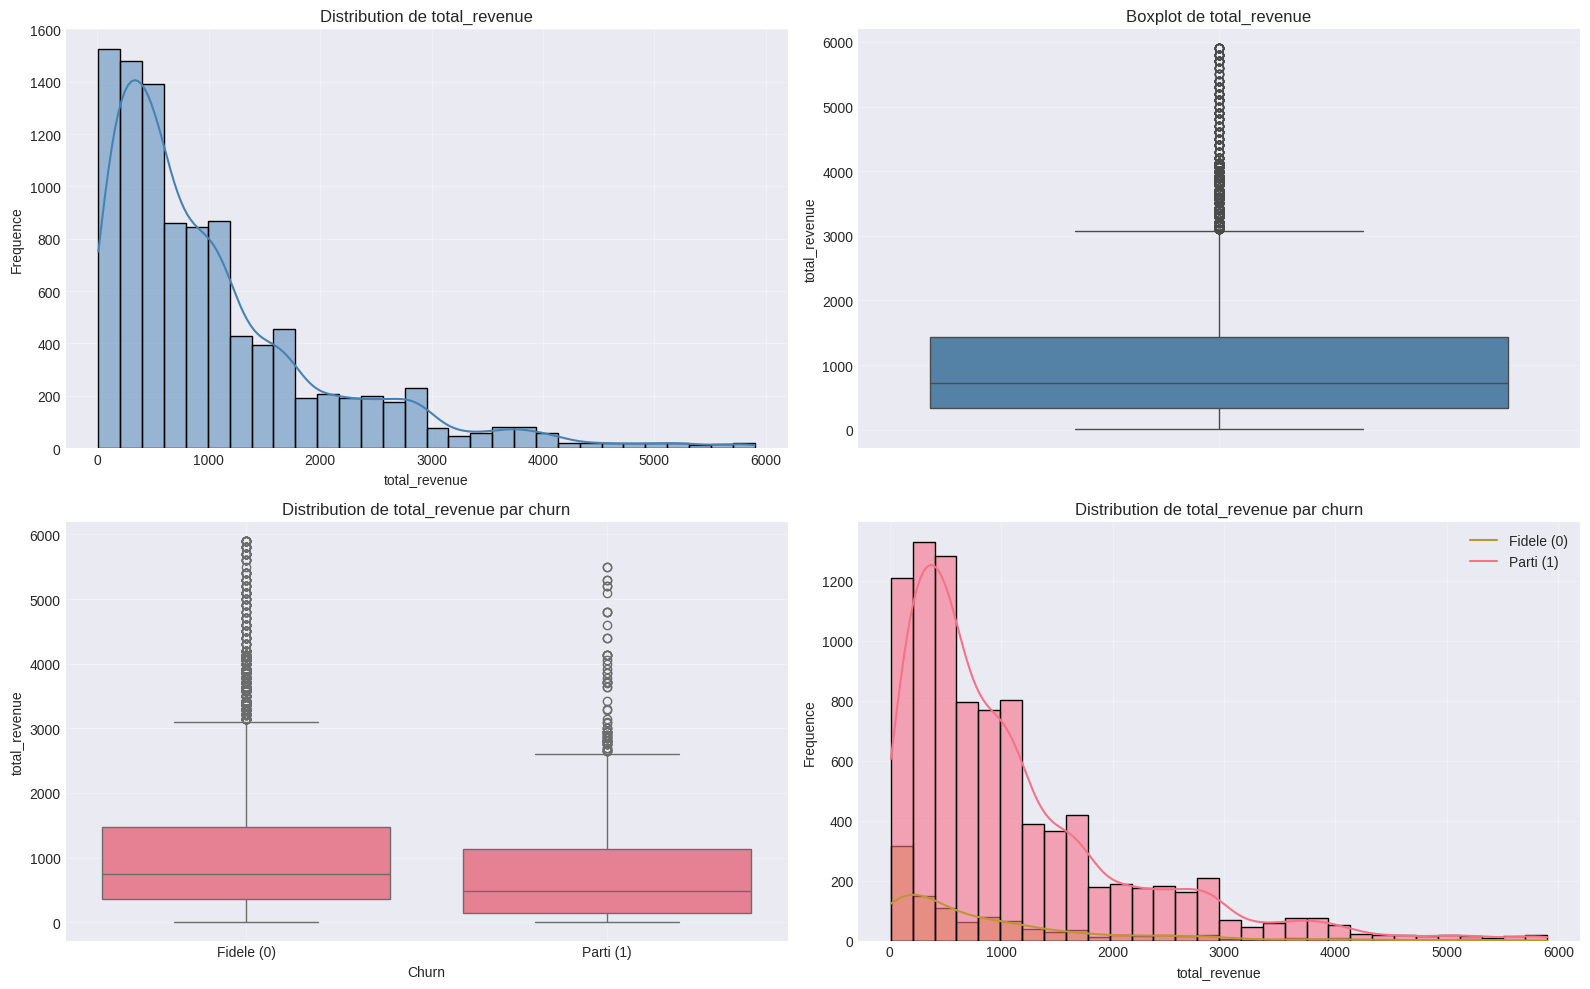

In [40]:
analyser_variable_numerique('total_revenue')

Cette variable `total_revenue` semble influencer la variable cible. La médiane du revenu est plus faible (490) chez les clients partis que chez les clients fidèles (750).

ANALYSE DE LA VARIABLE: PAYMENT_FAILURES

* Statistiques descriptives:
count    10000.000000
mean         0.501000
std          0.711934
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max          5.000000
Name: payment_failures, dtype: float64

* Statistiques par groupe:
        count      mean       std  min  25%  50%  75%  max
churn                                                     
0      8979.0  0.473995  0.683044  0.0  0.0  0.0  1.0  5.0
1      1021.0  0.738492  0.893976  0.0  0.0  0.0  1.0  5.0

Mediane clients fideles: 0.00
Mediane clients partis: 0.00
Ecart: 0.00


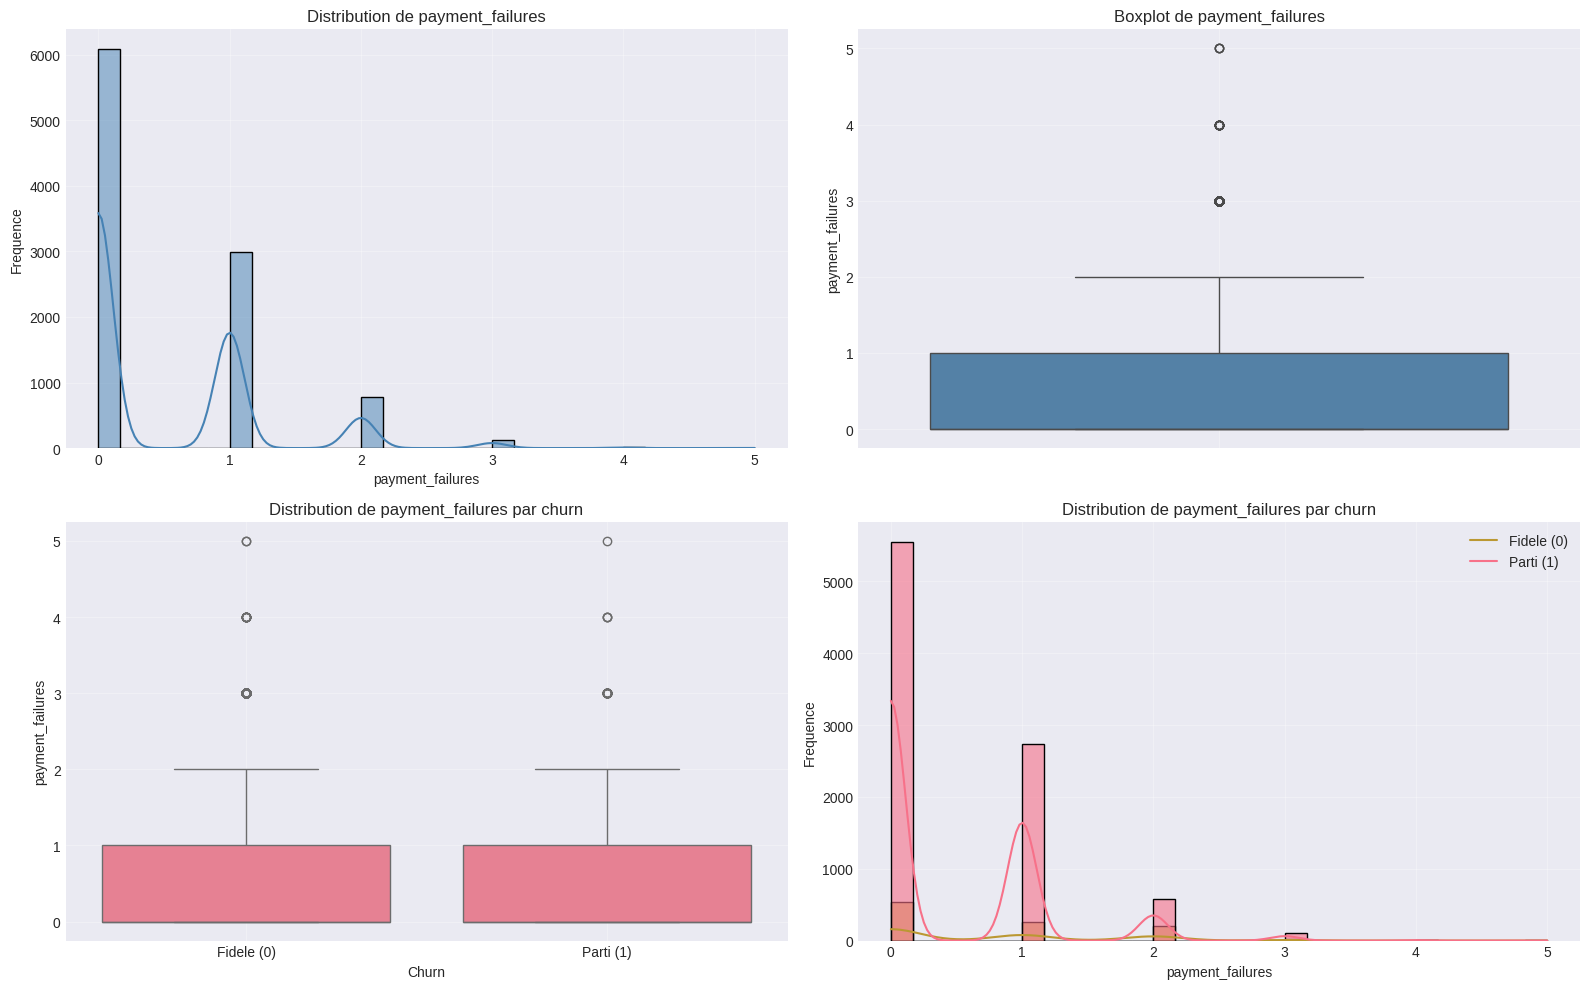

In [41]:
analyser_variable_numerique('payment_failures')

ANALYSE DE LA VARIABLE: SUPPORT_TICKETS

* Statistiques descriptives:
count    10000.000000
mean         1.206600
std          1.104554
min          0.000000
25%          0.000000
50%          1.000000
75%          2.000000
max          7.000000
Name: support_tickets, dtype: float64

* Statistiques par groupe:
        count      mean       std  min  25%  50%  75%  max
churn                                                     
0      8979.0  1.206482  1.105041  0.0  0.0  1.0  2.0  7.0
1      1021.0  1.207640  1.100793  0.0  0.0  1.0  2.0  7.0

Mediane clients fideles: 1.00
Mediane clients partis: 1.00
Ecart: 0.00


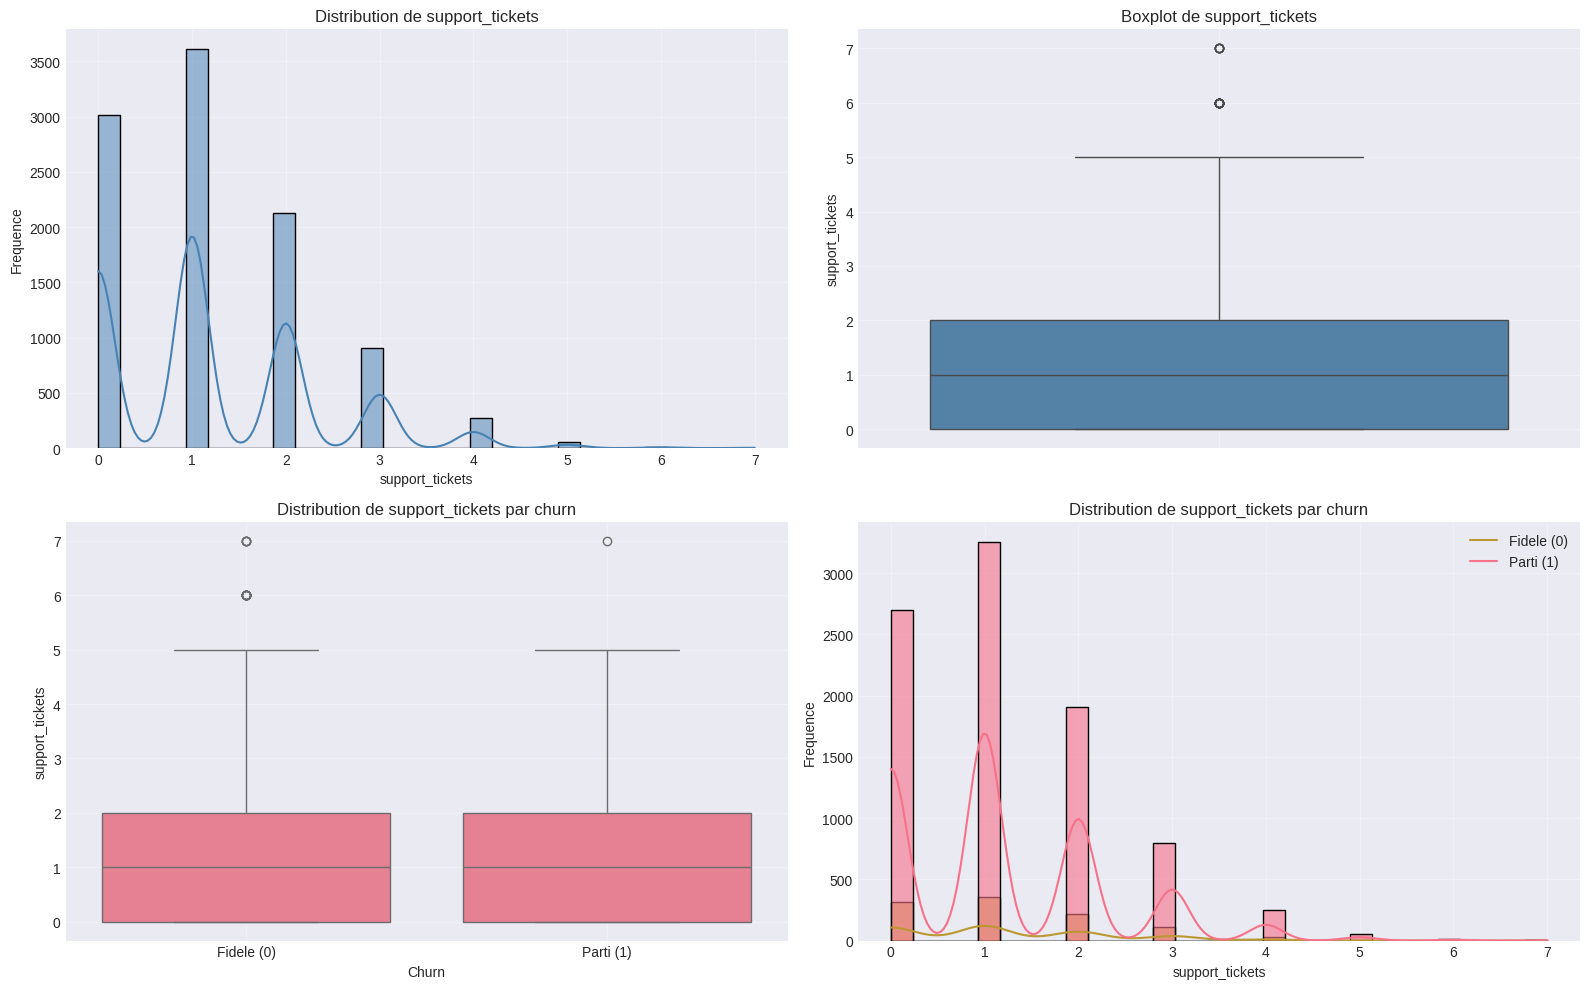

In [42]:
analyser_variable_numerique('support_tickets')

ANALYSE DE LA VARIABLE: AVG_RESOLUTION_TIME

* Statistiques descriptives:
count    10000.000000
mean        23.953210
std          9.956999
min          1.000000
25%         17.082041
50%         23.950444
75%         30.758480
max         61.821878
Name: avg_resolution_time, dtype: float64

* Statistiques par groupe:
        count       mean       std  min        25%        50%        75%  \
churn                                                                      
0      8979.0  23.984006  9.976488  1.0  17.140693  24.027393  30.765468   
1      1021.0  23.682382  9.784575  1.0  16.493213  23.471073  30.533395   

             max  
churn             
0      61.821878  
1      59.442810  

Mediane clients fideles: 24.03
Mediane clients partis: 23.47
Ecart: 0.56


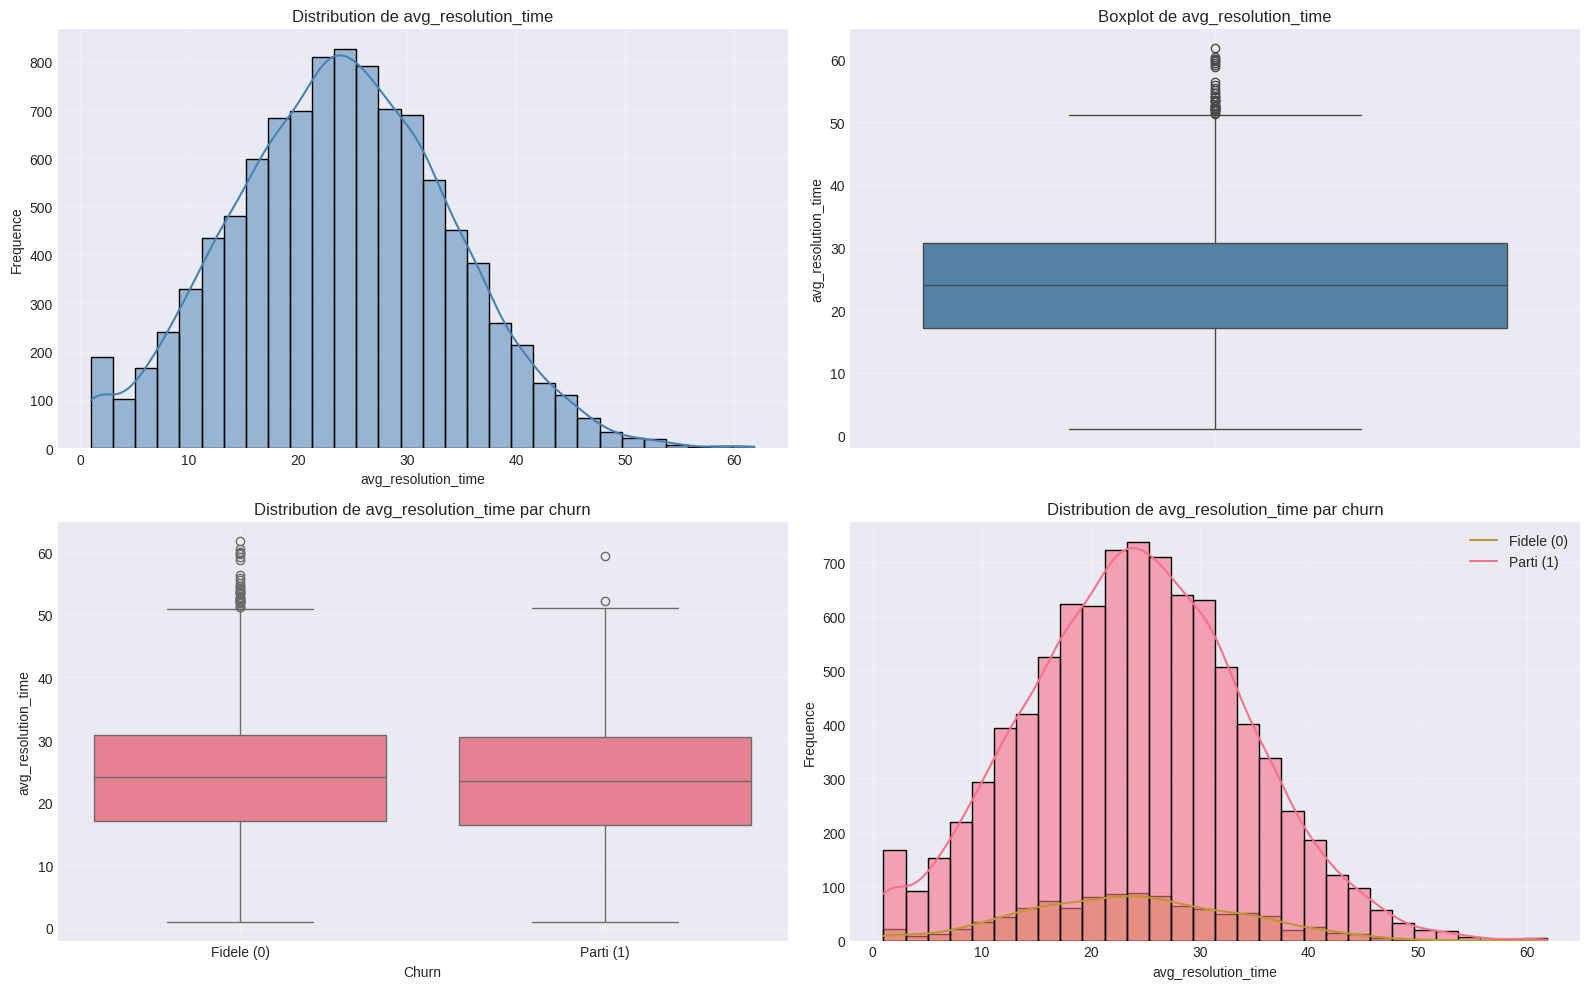

In [43]:
analyser_variable_numerique('avg_resolution_time')

ANALYSE DE LA VARIABLE: CSAT_SCORE

* Statistiques descriptives:
count    10000.000000
mean         3.486700
std          0.978631
min          1.000000
25%          3.000000
50%          4.000000
75%          4.000000
max          5.000000
Name: csat_score, dtype: float64

* Statistiques par groupe:
        count      mean       std  min  25%  50%  75%  max
churn                                                     
0      8979.0  3.538813  0.948039  1.0  3.0  4.0  4.0  5.0
1      1021.0  3.028404  1.115038  1.0  2.0  3.0  4.0  5.0

Mediane clients fideles: 4.00
Mediane clients partis: 3.00
Ecart: 1.00


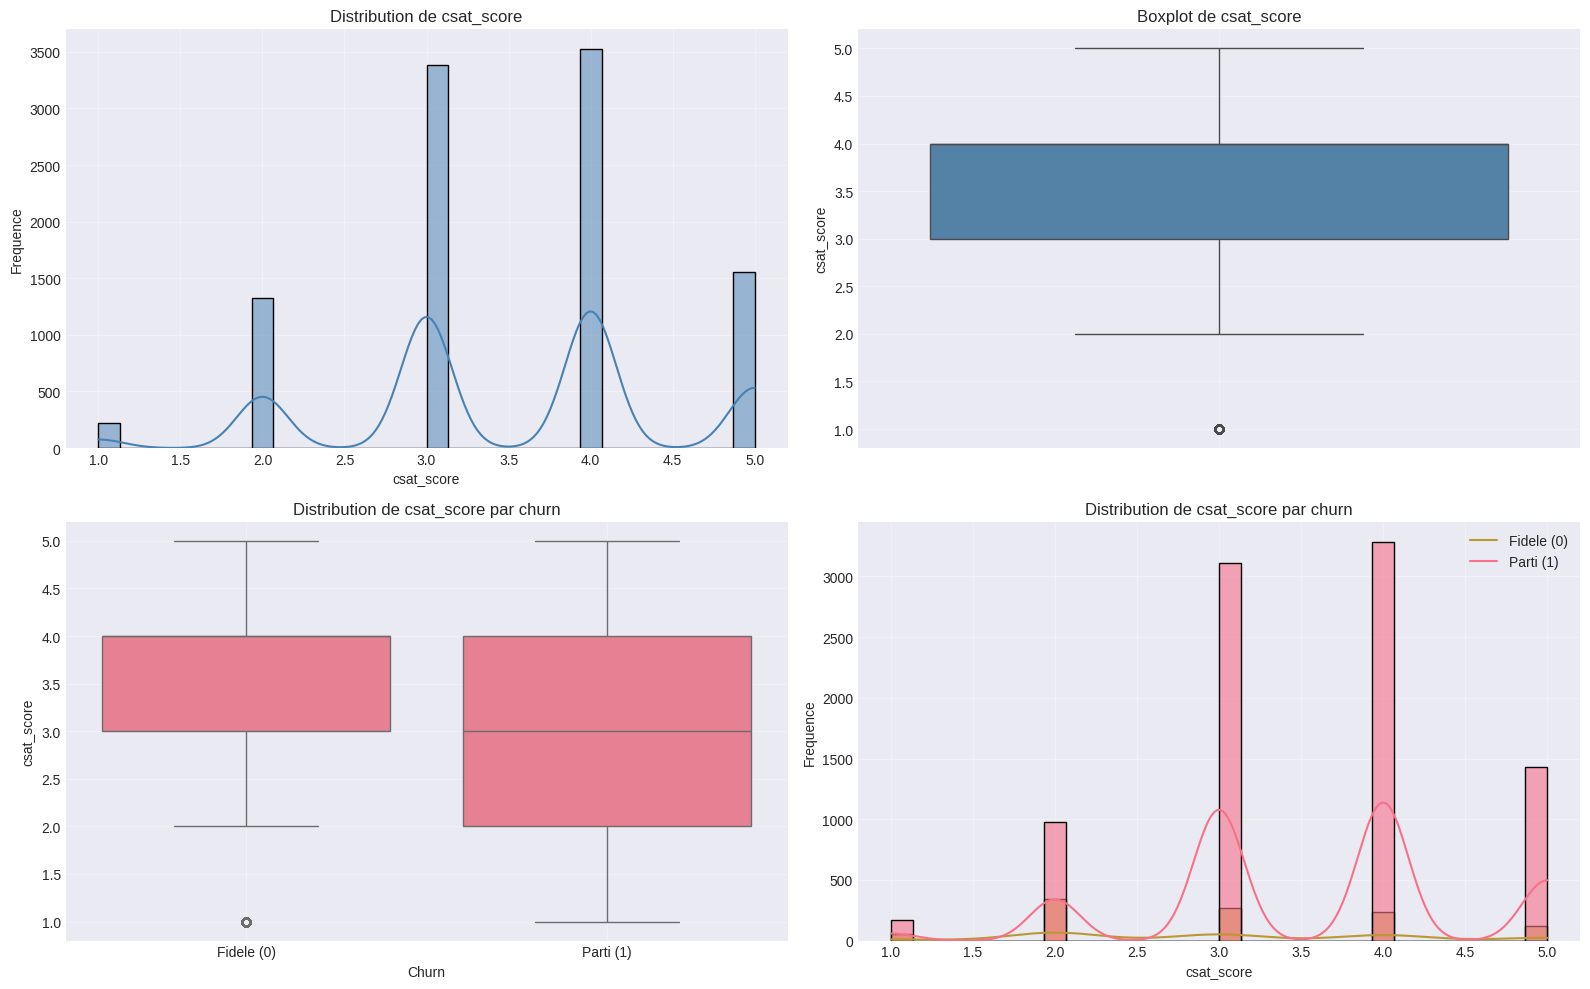

In [44]:
analyser_variable_numerique('csat_score')

ANALYSE DE LA VARIABLE: ESCALATIONS

* Statistiques descriptives:
count    10000.000000
mean         0.294100
std          0.543171
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max          4.000000
Name: escalations, dtype: float64

* Statistiques par groupe:
        count      mean       std  min  25%  50%  75%  max
churn                                                     
0      8979.0  0.292349  0.541606  0.0  0.0  0.0  1.0  4.0
1      1021.0  0.309500  0.556775  0.0  0.0  0.0  1.0  3.0

Mediane clients fideles: 0.00
Mediane clients partis: 0.00
Ecart: 0.00


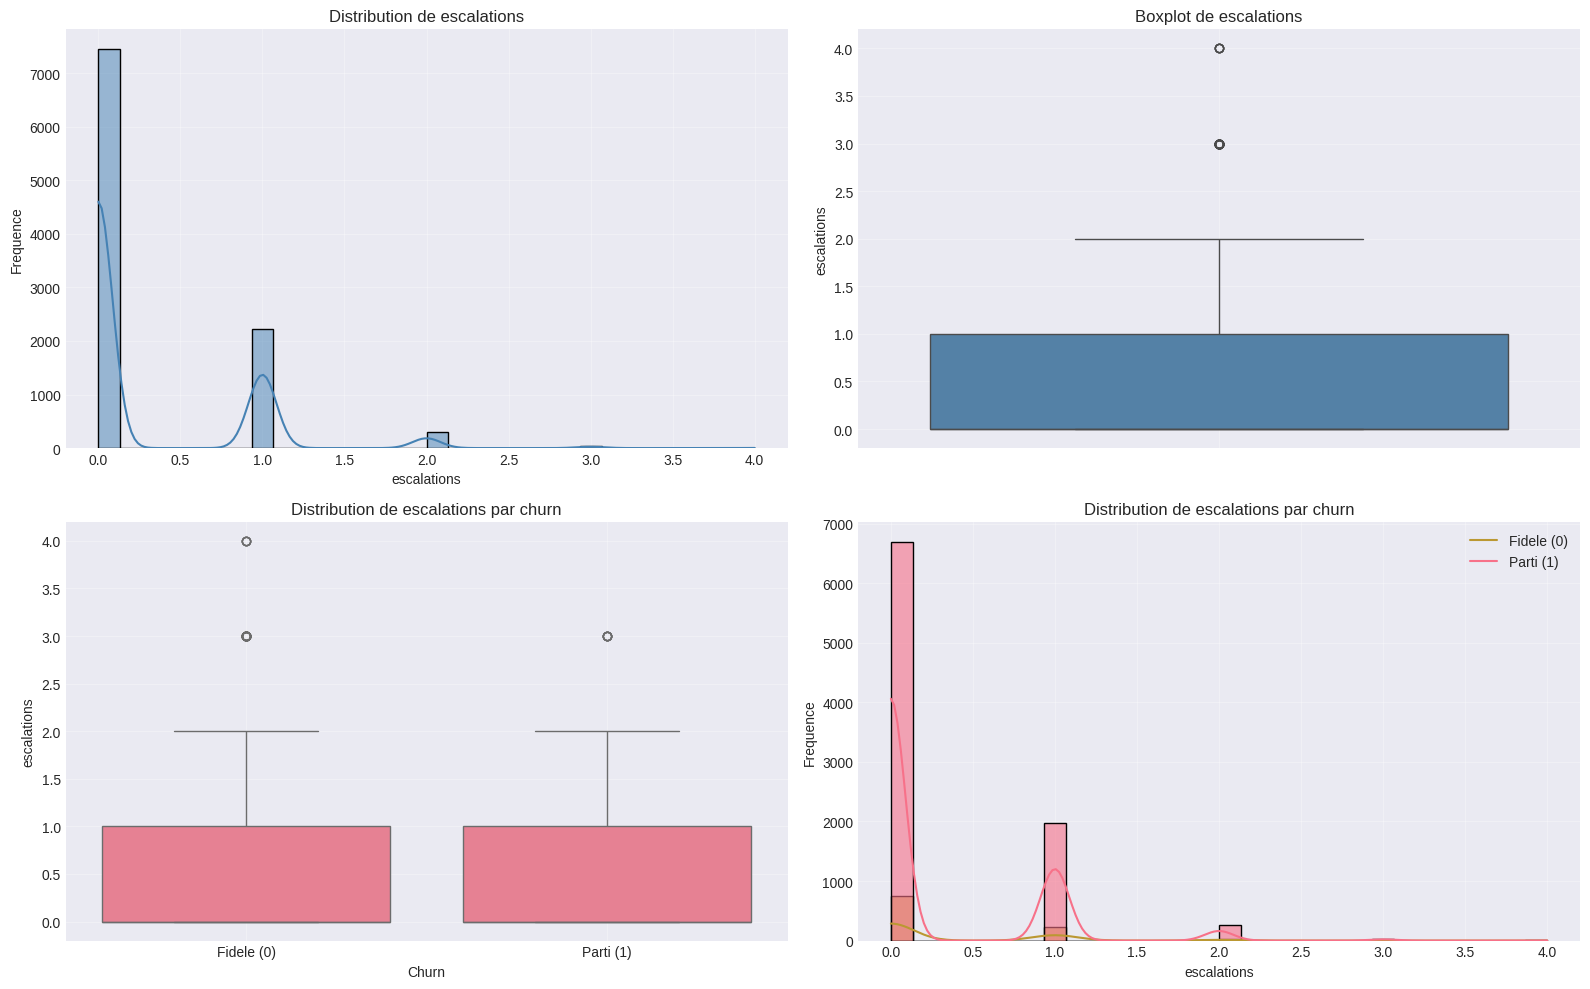

In [45]:
analyser_variable_numerique('escalations')

ANALYSE DE LA VARIABLE: EMAIL_OPEN_RATE

* Statistiques descriptives:
count    10000.000000
mean         0.499610
std          0.231601
min          0.100000
25%          0.300000
50%          0.500000
75%          0.700000
max          0.900000
Name: email_open_rate, dtype: float64

* Statistiques par groupe:
        count      mean       std  min   25%   50%  75%  max
churn                                                       
0      8979.0  0.498711  0.232115  0.1  0.30  0.50  0.7  0.9
1      1021.0  0.507512  0.226985  0.1  0.31  0.51  0.7  0.9

Mediane clients fideles: 0.50
Mediane clients partis: 0.51
Ecart: 0.01


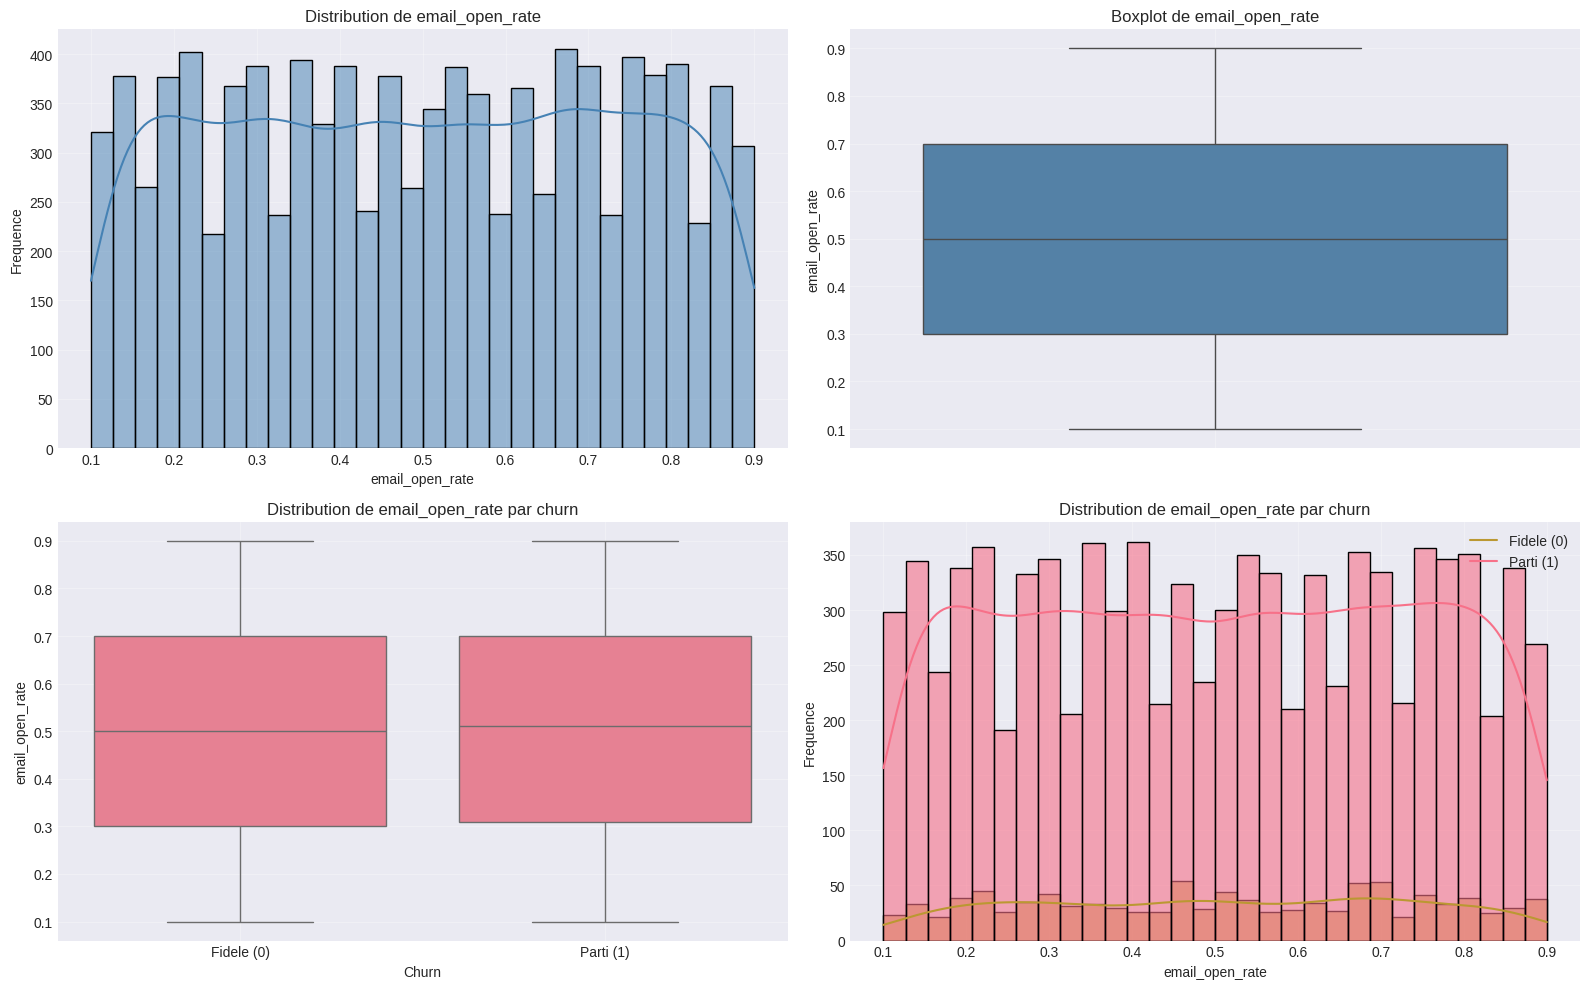

In [46]:
analyser_variable_numerique('email_open_rate')

ANALYSE DE LA VARIABLE: MARKETING_CLICK_RATE

* Statistiques descriptives:
count    10000.000000
mean         0.253575
std          0.140532
min          0.010000
25%          0.130000
50%          0.250000
75%          0.380000
max          0.500000
Name: marketing_click_rate, dtype: float64

* Statistiques par groupe:
        count      mean       std   min   25%   50%   75%  max
churn                                                         
0      8979.0  0.253673  0.140403  0.01  0.13  0.25  0.38  0.5
1      1021.0  0.252713  0.141726  0.01  0.13  0.25  0.38  0.5

Mediane clients fideles: 0.25
Mediane clients partis: 0.25
Ecart: 0.00


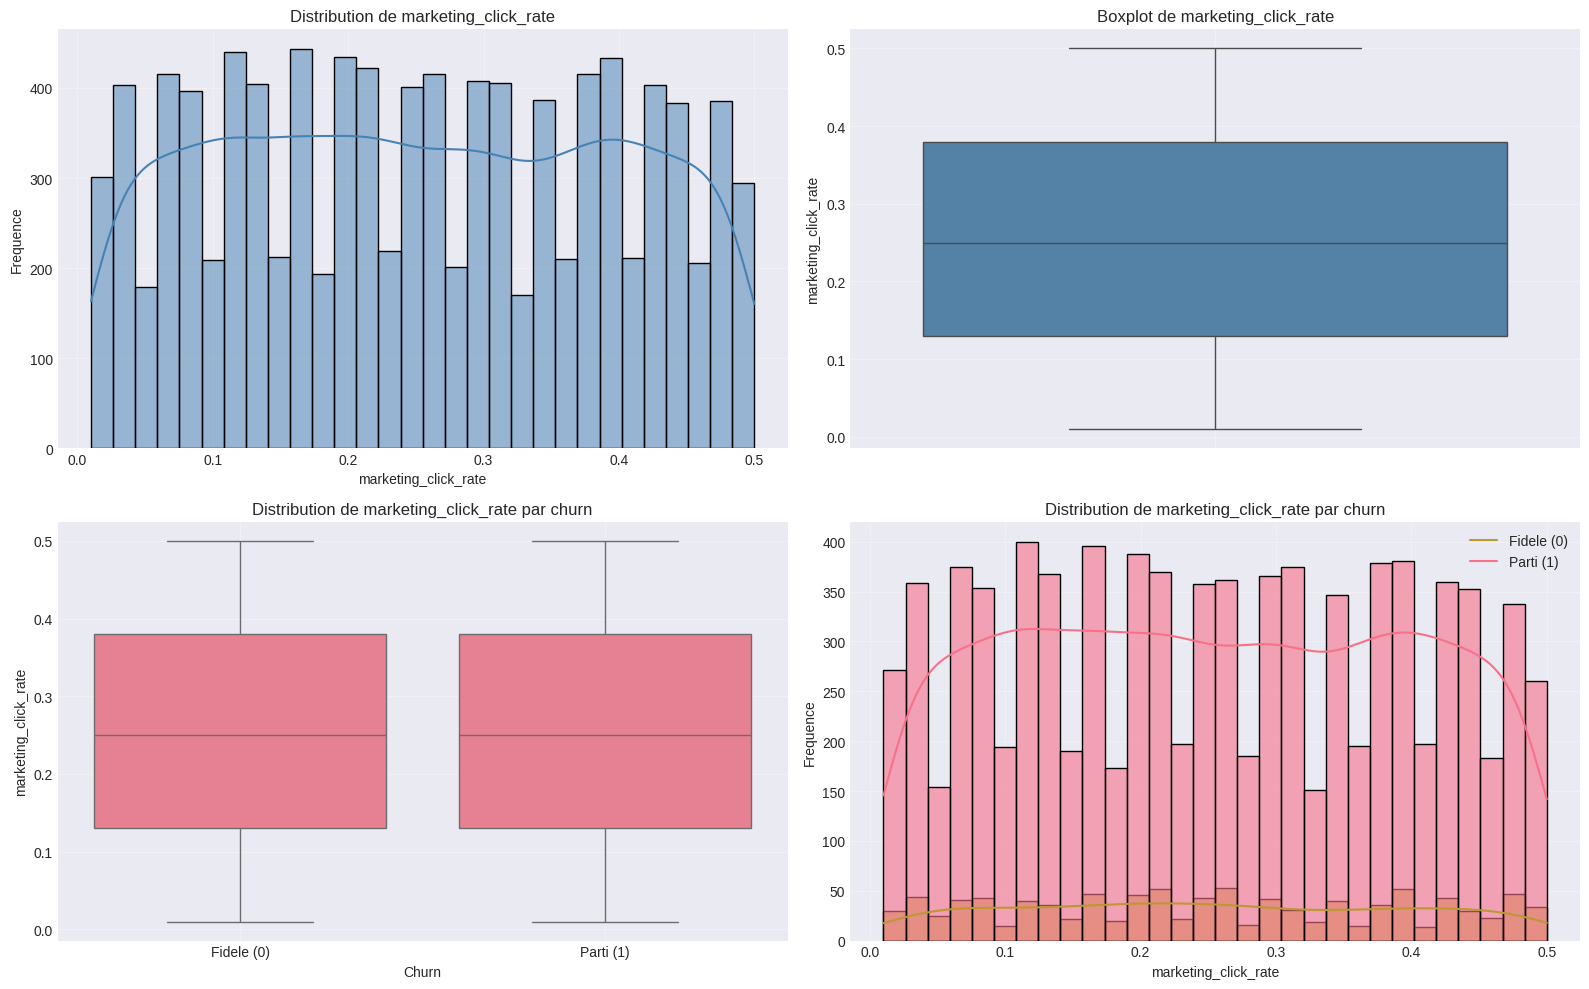

In [47]:
analyser_variable_numerique('marketing_click_rate')

ANALYSE DE LA VARIABLE: NPS_SCORE

* Statistiques descriptives:
count    10000.000000
mean        19.110500
std         38.936619
min       -100.000000
25%         -7.000000
50%         19.000000
75%         46.000000
max        100.000000
Name: nps_score, dtype: float64

* Statistiques par groupe:
        count       mean        std    min  25%   50%   75%    max
churn                                                             
0      8979.0  19.071166  39.067197 -100.0 -7.0  19.0  46.0  100.0
1      1021.0  19.456415  37.785713  -95.0 -5.0  18.0  45.0  100.0

Mediane clients fideles: 19.00
Mediane clients partis: 18.00
Ecart: 1.00


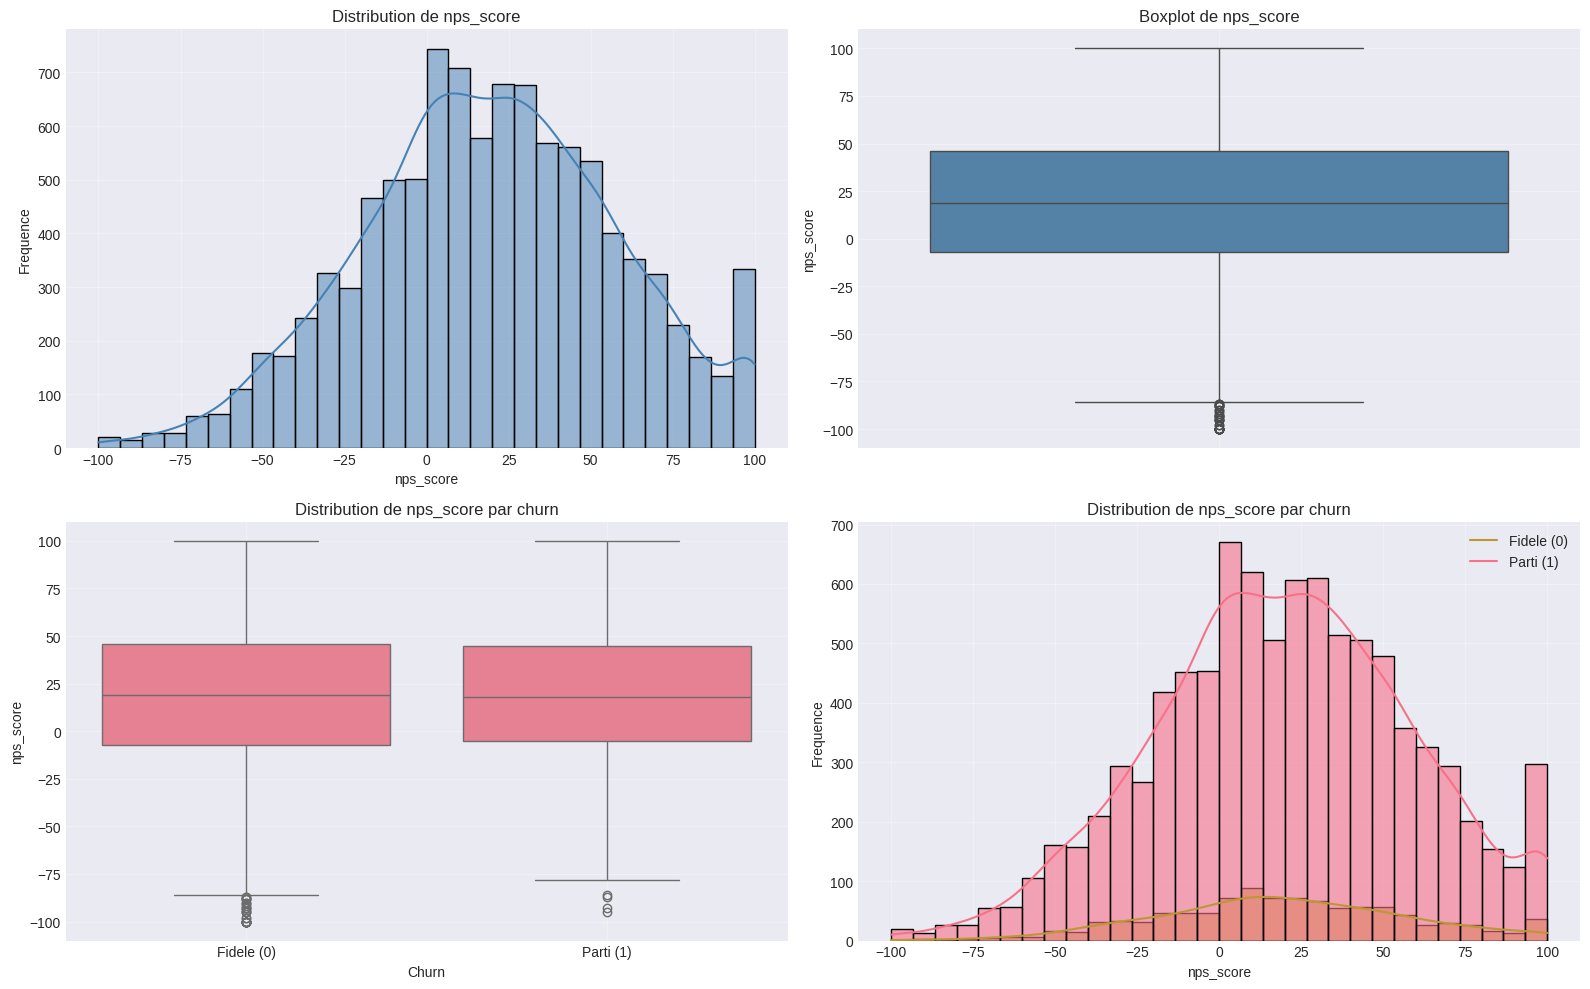

In [48]:
analyser_variable_numerique('nps_score')

ANALYSE DE LA VARIABLE: REFERRAL_COUNT

* Statistiques descriptives:
count    10000.0000
mean         0.9922
std          0.9939
min          0.0000
25%          0.0000
50%          1.0000
75%          2.0000
max          7.0000
Name: referral_count, dtype: float64

* Statistiques par groupe:
        count      mean       std  min  25%  50%  75%  max
churn                                                     
0      8979.0  0.994654  0.995968  0.0  0.0  1.0  2.0  7.0
1      1021.0  0.970617  0.975744  0.0  0.0  1.0  2.0  5.0

Mediane clients fideles: 1.00
Mediane clients partis: 1.00
Ecart: 0.00


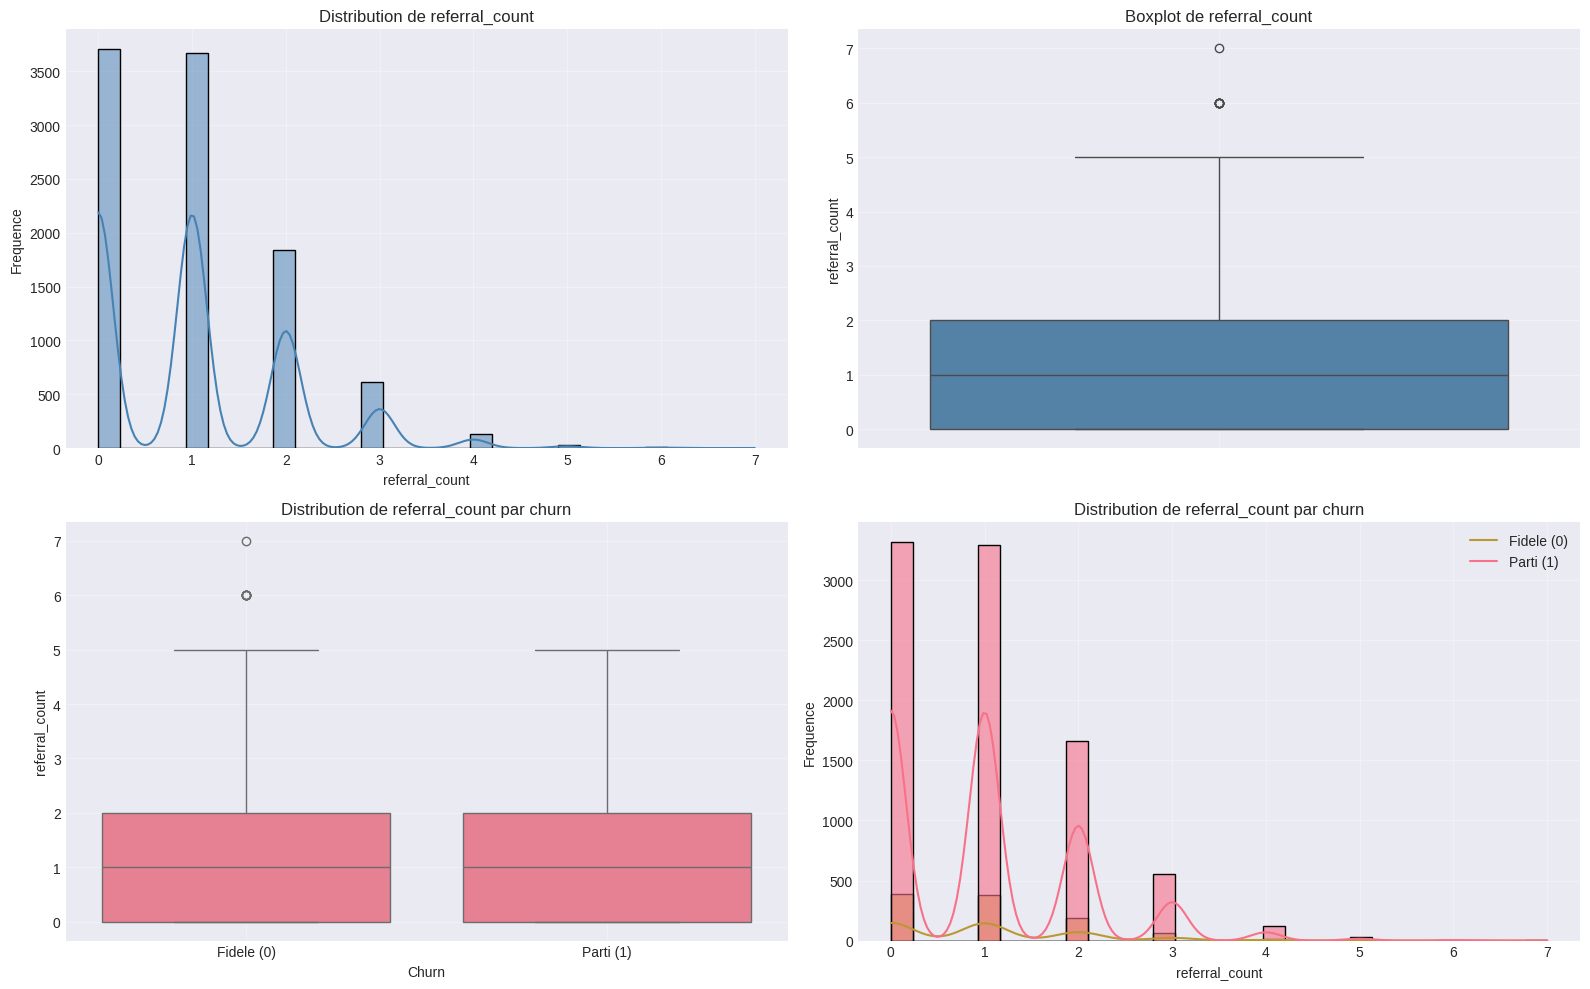

In [49]:
analyser_variable_numerique('referral_count')

---

### Mini conclusion EDA : Analyse des Variables Numériques

#### Variables à faible pouvoir prédictif

Les variables suivantes présentent des distributions similaires entre clients fidèles et clients partis :
- `age`
- `weekly_active_days`
- `avg_session_time`
- `features_used`
- `usage_growth_rate`
- `last_login_days_ago`
- `monthly_fee`
- `payment_failures`
- `support_tickets`
- `avg_resolution_time`
- `csat_score`
- `escalations`
- `email_open_rate`
- `marketing_click_rate`
- `nps_score`
- `referral_count`

Ces variables montrent peu de différences dans les médianes entre les deux groupes et seront conservées pour la modélisation mais pourraient avoir une contribution limitée.

#### Variables à pouvoir prédictif notable

Les variables suivantes montrent des différences significatives entre churners et non-churners :

1. **`tenure_months`** (ancienneté)
   - Médiane clients fidèles : 31 mois
   - Médiane clients partis : 22 mois
   - Écart : 9 mois
   - **Insight** : Les clients récents sont plus à risque de churn
   - **Hypothèse métier** : Phase critique d'onboarding, manque d'ancrage produit

2. **`monthly_logins`** (fréquence de connexion)
   - Médiane plus faible chez les clients partis
   - **Insight** : La baisse d'engagement est un signal précoce de churn
   - **Hypothèse métier** : Désengagement progressif avant résiliation

3. **`total_revenue`** (revenu généré)
   - Médiane clients fidèles : 750$
   - Médiane clients partis : 490$
   - Écart : 260$
   - **Insight** : Les clients à faible revenu sont plus susceptibles de partir
   - **Hypothèse métier** : Clients moins investis ou offre inadaptée à leur usage

#### Synthèse et implications pour la modélisation

Les trois variables les plus discriminantes sont :
1. **`tenure_months`** : Ancienneté critique
2. **`monthly_logins`** : Engagement comportemental
3. **`total_revenue`** : Valeur client

Ces variables reflètent trois dimensions complémentaires du risque de churn : la maturité client, l'engagement actif et la valeur économique. Elles devront être priorisées lors de la construction des modèles et du feature engineering.

## Traitement des valeurs manquantes

In [50]:
df.isnull().sum()

customer_id                  0
gender                       0
age                          0
country                      0
city                         0
customer_segment             0
tenure_months                0
signup_channel               0
contract_type                0
monthly_logins               0
weekly_active_days           0
avg_session_time             0
features_used                0
usage_growth_rate            0
last_login_days_ago          0
monthly_fee                  0
total_revenue                0
payment_method               0
payment_failures             0
discount_applied             0
price_increase_last_3m       0
support_tickets              0
avg_resolution_time          0
complaint_type            2045
csat_score                   0
escalations                  0
email_open_rate              0
marketing_click_rate         0
nps_score                    0
survey_response              0
referral_count               0
churn                        0
dtype: i

In [51]:
df["complaint_type"].value_counts()

complaint_type
Technical    3498
Billing      2427
Service      2030
Name: count, dtype: int64

Nous n'avons des données manquantes que pour la variable `complaint_type` (20% de valeurs nulles). Nous allons imputer ces valeurs manquantes avec la modalité "No_Complaint" pour créer une catégorie distincte.

In [52]:
df["complaint_type"] = df["complaint_type"].fillna('No_Complaint')

## Matrice de corrélation

Nous allons afficher une matrice de corrélation pour les variables numériques

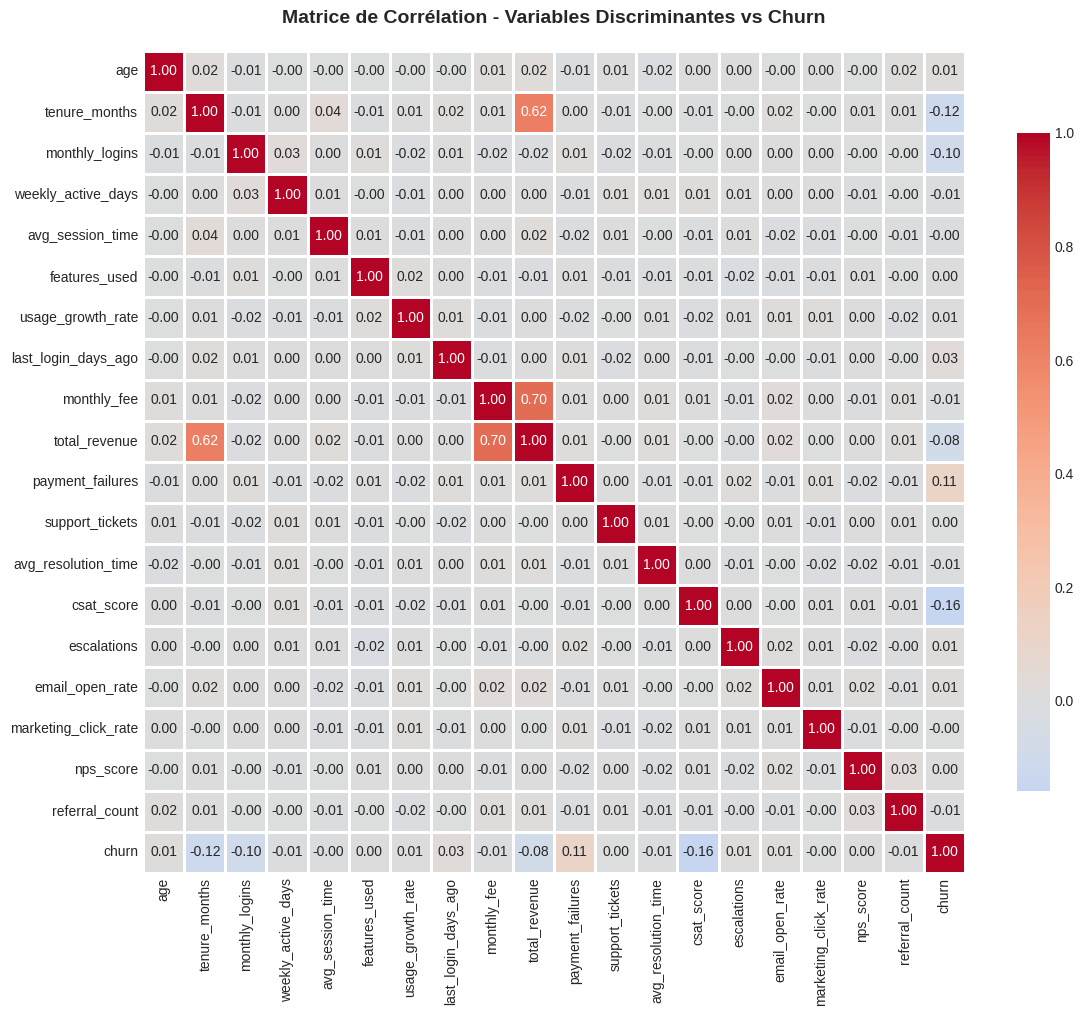

In [66]:
# Préparation des données pour la matrice de corrélation
from sklearn.preprocessing import LabelEncoder

df_corr = df[variables_numeriques + ['churn']].copy()

correlation_matrix = df_corr.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Matrice de Corrélation - Variables Discriminantes vs Churn', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig(IMG_PATH / "eda_matrice_correlation.png")
plt.show()

In [68]:
correlation_matrix['churn'].sort_values(ascending=False)

churn                   1.000000
payment_failures        0.112494
last_login_days_ago     0.025543
email_open_rate         0.011506
age                     0.010155
escalations             0.009561
usage_growth_rate       0.005203
features_used           0.004433
nps_score               0.002996
support_tickets         0.000317
marketing_click_rate   -0.002068
avg_session_time       -0.004543
monthly_fee            -0.005171
referral_count         -0.007323
weekly_active_days     -0.008818
avg_resolution_time    -0.009172
total_revenue          -0.077944
monthly_logins         -0.098339
tenure_months          -0.117014
csat_score             -0.157924
Name: churn, dtype: float64

Au niveau de la matrice de correlation, rien est fortement corrélé avec la variable cible `churn`. Cependant, on peut noter que les variables `csat_score`, `tenure_months` et `monthly_logins` présentent une corrélation négative modérée avec le churn, ce qui confirme les observations faites lors de l'analyse univariée. Ces variables seront des candidates importantes pour la modélisation prédictive du churn. Egalement la variabble `payment_failures` est légèrement corrélée positivement avec le churn, ce qui suggère que les clients ayant des échecs de paiement sont plus susceptibles de résilier leur abonnement.

## Traitement des outliers

Nous avons détecté lors des étapes précédentes la présence de valeurs extrêmes dans certaines variables numériques. Nous allons ici dans un premier temps les identifier et les visualiser.

In [55]:
variables_outliers = [
    "avg_session_time",
    "features_used",
    "usage_growth_rate",
    "last_login_days_ago",
    "monthly_fee",
    "total_revenue",
]

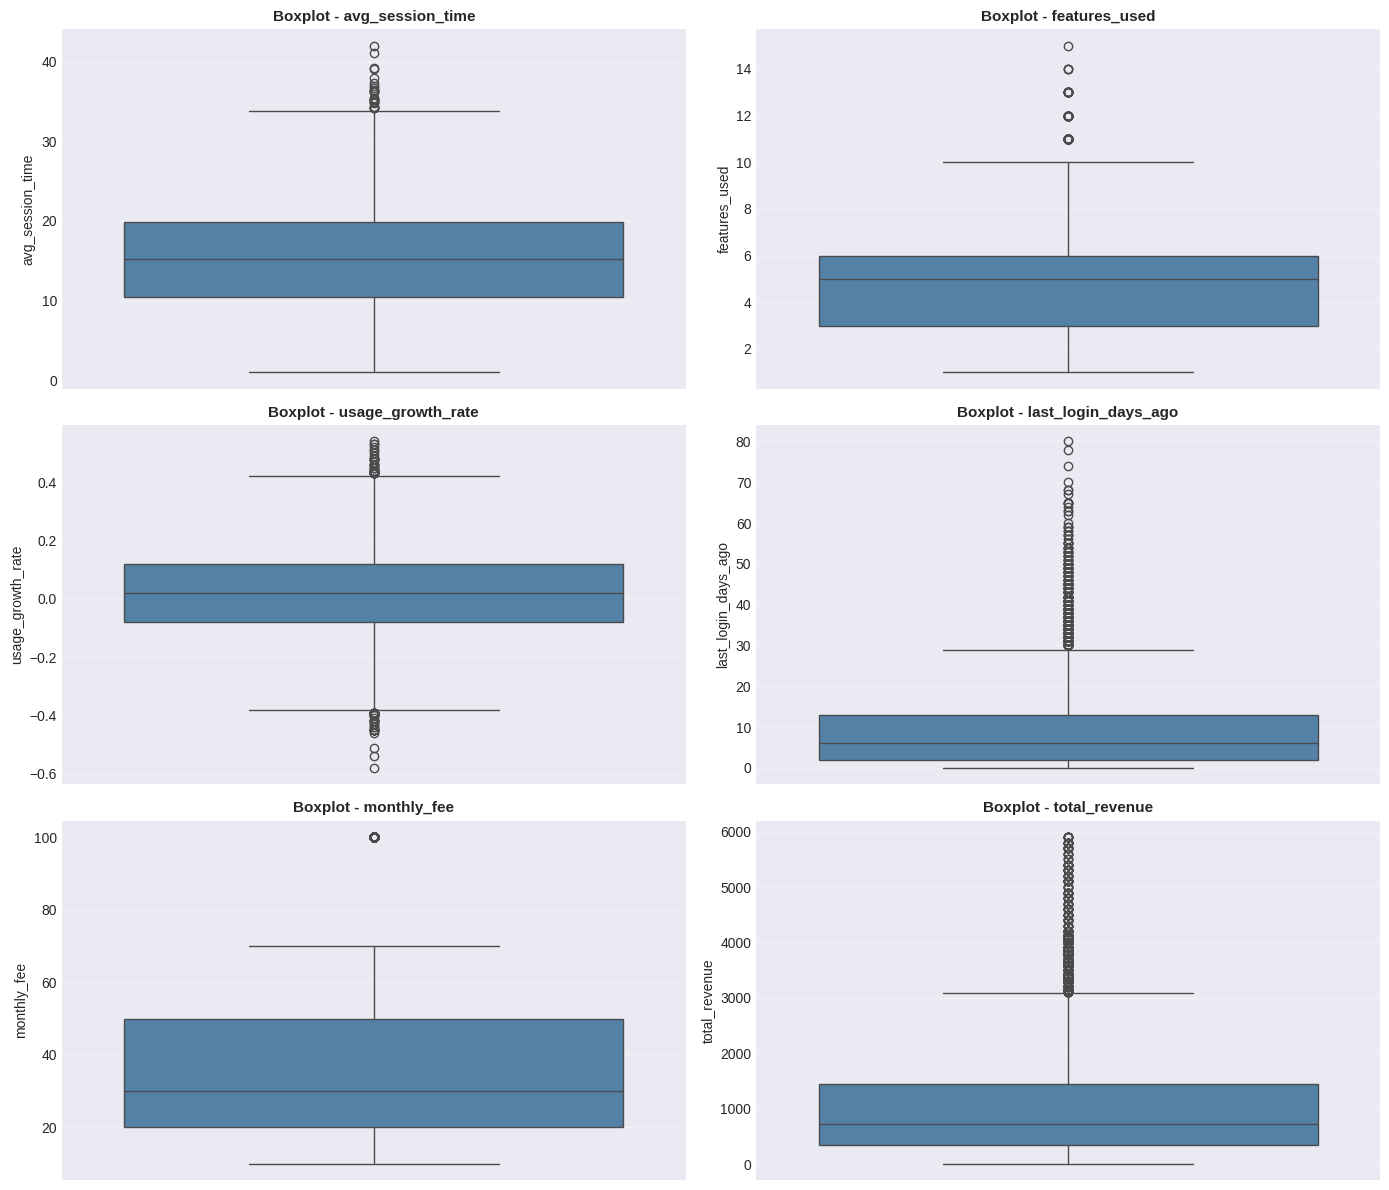

In [56]:
# Visualisation des boxplots pour détecter les outliers
fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.ravel()

for i, var in enumerate(variables_outliers):
    sns.boxplot(data=df, y=var, ax=axes[i], color='steelblue')
    axes[i].set_title(f'Boxplot - {var}', fontsize=11, fontweight='bold')
    axes[i].set_ylabel(var, fontsize=10)
    axes[i].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(IMG_PATH / "eda_outliers_boxplots.png")
plt.show()

In [57]:
def detecter_outliers_iqr(data, variable):
    """Détecte les outliers d'une variable numérique à l'aide de la méthode IQR."""
    Q1 = data[variable].quantile(0.25)
    Q3 = data[variable].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    # outliers = data[(data[variable] < lower_bound) | (data[variable] > upper_bound)]
    return lower_bound, upper_bound

In [58]:
for col in variables_outliers:
    lower, upper = detecter_outliers_iqr(df, col)
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"Variable : {col}, remplacement de {len(outliers)} outliers par les bornes")
    df[col] = df[col].clip(lower=lower, upper=upper)

Variable : avg_session_time, remplacement de 27 outliers par les bornes
Variable : features_used, remplacement de 121 outliers par les bornes
Variable : usage_growth_rate, remplacement de 78 outliers par les bornes
Variable : last_login_days_ago, remplacement de 471 outliers par les bornes
Variable : monthly_fee, remplacement de 513 outliers par les bornes
Variable : total_revenue, remplacement de 513 outliers par les bornes


Nous utilisons la méthode de l'IQR pour détecter les outliers. Pour chacune des variables concernées, nous avons remplacé les valeurs extrêmes par les bornes inférieure et supérieure définies par la méthode IQR. Cette approche permet de limiter l'impact des outliers tout en conservant l'intégrité des données.

---

## 🎯 Conclusion Générale de l'Analyse Exploratoire (EDA)

### Principaux Constats

**1. Déséquilibre des classes**
- Ratio 90/10 (fidèles/churners) nécessitant une stratégie adaptée (class_weight, SMOTE, métriques Recall/F1)

**2. Variables les plus discriminantes identifiées**

**Variables numériques** :
- **`tenure_months`** : Écart de 9 mois (22 vs 31) → nouveaux clients plus à risque
- **`monthly_logins`** : Désengagement = signal précoce de churn
- **`total_revenue`** : Écart de 260$ (490 vs 750) → clients à faible valeur plus volatiles

**Variables catégorielles** :
- **`customer_segment`** : Segment SME plus sensible au churn
- **`signup_channel`** : Canal Referral associé à un risque élevé
- **`survey_response`** : Insatisfaction = indicateur fort de résiliation
- **`city`** : Variations géographiques (NY, Toronto, Sydney > Londres, Berlin)

**3. Valeurs manquantes**
- Uniquement `complaint_type` (20%) → imputation avec "No_Complaint"

**4. Corrélations**
- Analyse de corrélation confirme les variables identifiées visuellement
- Pas de multicolinéarité excessive détectée

**5. Outliers**
- Présence d'outliers dans certaines variables numériques
- Traitement par méthode IQR pour limiter leur impact tout en conservant l'intégrité des données
